# Read datasets

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
from typing import  Dict
import warnings
warnings.filterwarnings('ignore')

`camel_data -i light`

Downloads required resources, including:
morphology database (calima-msa)
Stores them here: `C:\Users\msi\AppData\Roaming\camel_tools\data\`



In [2]:
from camel_tools.morphology.database import MorphologyDB
from camel_tools.morphology.analyzer import Analyzer

db = MorphologyDB.builtin_db()
analyzer = Analyzer(db)

In [3]:
BASE_PATH = Path('g:/FreeLance/Mostaqel/QSE/Data')
df_linguistic = pd.read_csv(BASE_PATH / 'Linguistic' / 'Quranic.csv', sep='\t', encoding='utf-16')
df_subjective = pd.read_csv(BASE_PATH / 'Subjective' / 'Quranic_Tags.csv', encoding='utf-8')
df_interpretation = pd.read_csv(BASE_PATH / 'Interpretation' / 'ar.muyassar.csv', encoding='utf-8')
display(df_linguistic.sample(3))
display(df_subjective.sample(3))
display(df_interpretation.sample(3))

,tid,sentence_id,sentence_word,token_id,location,chapter_id,verse_id,word_id,tok_id,uthmani_token,...,person,gender,number,rel_label,rel_label_ar,ref_token_id,is_constituent,constituents_loc,constituents,constituent_label
116664,116664,9662,2,3,(46:4:19:1),46,4,19,1,ب,...,_,_,_,link,متعلق,0,1,[3-4],بكتبٍ,PP
39288,39288,3354,2,3,(7:158:2:2),7,158,2,2,أَيُّهَا,...,_,_,_,voc,منادى,2,0,_,_,-
102662,102662,8430,1,0,(36:38:5:1),36,38,5,1,ذلك,...,_,M,S,root,root,0,-1,_,_,_


,Surah,Ayah,Arabic,Urdu,English,Tags,Category,Emotion,Context
2681,23,9,وَالَّذِينَ هُمْ عَلَىٰ صَلَوَاتِهِمْ يُحَافِظ...,اور جو نمازوں کی پابندی کرتے ہیں,And who pay heed to their prayers.,Prayer,Worship (‘Ibadah),Determination,Worship guidance
3252,28,1,بِسْمِ اللَّهِ الرَّحْمَٰنِ الرَّحِيمِ طسم,طٰسٓمٓ,Ta. Sin. Mim.,Revelation,Divine Attributes & Signs (Asma wa Sifat),Awe,Makki Revelation
3387,29,48,وَمَا كُنْتَ تَتْلُو مِنْ قَبْلِهِ مِنْ كِتَاب...,اور تم اس سے پہلے کوئی کتاب نہیں پڑھتے تھے اور...,And thou (O Muhammad) wast not a reader of any...,"Revelation, Prophethood, Knowledge, Guidance, ...",Faith (Aqeedah),Awe,Makki Revelation


,Surah,Verse,Tafsir
1433,10,70,إنما يتمتعون في الدنيا بكفرهم وكذبهم متاعًا قص...
5607,76,17,ويدور عليهم الخدم بأواني الطعام الفضيَّة، وأكو...
700,5,32,بسبب جناية القتل هذه شَرَعْنا لبني اسرائيل أنه...


In [4]:
# Making a dictionary to map the roots to the surahs 
# surah is the chapter of the Quran, and root is the root word from which the verse is derived.
# we have 114 surahs for each of them we would have a list of roots that are present in that surah. 
root_to_surahs = {}
for index, row in df_linguistic.iterrows():
    surah = row['root_ar']
    root = row['chapter_id']
    if root not in root_to_surahs:
        root_to_surahs[root] = set()
    root_to_surahs[root].add(surah)


In [5]:
# create a dataframe to display each surah and the number of unique roots in that surah and a column with separated list of the unique roots in that surah.
surah_root_counts = []
for root, surahs in root_to_surahs.items(): 
    surah_root_counts.append({
        'surah': root,
        'unique_root_count': len(surahs),
        'unique_roots': ', '.join(surahs)
    })
df_surah_root_counts = pd.DataFrame(surah_root_counts)
display(df_surah_root_counts.head())


,surah,unique_root_count,unique_roots
0,1,19,"ـ, دين, غضب, ملك, سمو, ضلل, غير, صرط, علم, هدي..."
1,2,586,"نظر, مصر, عشر, هات, ثقف, عزل, طيب, ندو, عنب, ر..."
2,3,440,"زبر, نظر, ثقف, كبت, طيب, ندو, رضو, ملك, ضجع, ت..."
3,4,463,"زبر, نظر, عشر, ثقف, عزل, طيب, رضو, ملك, ضجع, ت..."
4,5,423,"نظر, عشر, طيب, ندو, ندم, رضو, ملك, تحت, ولد, ف..."


In [6]:
# complete mapping of surah names (common English transliterations) to chapter ids (1-114)
surah_name_en_to_id = {
    'Al-Fatiha': 1,
    'Al-Baqarah': 2,
    'Al-Imran': 3,
    'An-Nisa': 4,
    "Al-Ma'idah": 5,
    "Al-An'am": 6,
    "Al-A'raf": 7,
    'Al-Anfal': 8,
    'At-Tawbah': 9,
    'Yunus': 10,
    'Hud': 11,
    'Yusuf': 12,
    "Ar-Ra'd": 13,
    'Ibrahim': 14,
    'Al-Hijr': 15,
    'An-Nahl': 16,
    'Al-Isra': 17,
    'Al-Kahf': 18,
    'Maryam': 19,
    'Ta-Ha': 20,
    'Al-Anbiya': 21,
    'Al-Hajj': 22,
    "Al-Mu'minun": 23,
    'An-Nur': 24,
    'Al-Furqan': 25,
    "Ash-Shu'ara": 26,
    'An-Naml': 27,
    'Al-Qasas': 28,
    'Al-Ankabut': 29,
    'Ar-Rum': 30,
    'Luqman': 31,
    'As-Sajda': 32,
    'Al-Ahzab': 33,
    'Saba': 34,
    'Fatir': 35,
    'Ya-Sin': 36,
    'As-Saffat': 37,
    'Sad': 38,
    'Az-Zumar': 39,
    'Ghafir': 40,
    'Fussilat': 41,
    'Ash-Shura': 42,
    'Az-Zukhruf': 43,
    'Ad-Dukhan': 44,
    'Al-Jathiya': 45,
    'Al-Ahqaf': 46,
    'Muhammad': 47,
    'Al-Fath': 48,
    'Al-Hujurat': 49,
    'Qaf': 50,
    "Adh-Dhariyat": 51,
    'At-Tur': 52,
    'An-Najm': 53,
    'Al-Qamar': 54,
    'Ar-Rahman': 55,
    "Al-Waqi'a": 56,
    'Al-Hadid': 57,
    'Al-Mujadila': 58,
    'Al-Hashr': 59,
    'Al-Mumtahanah': 60,
    'As-Saff': 61,
    "Al-Jumu'ah": 62,
    'Al-Munafiqun': 63,
    'At-Taghabun': 64,
    'At-Talaq': 65,
    'At-Tahrim': 66,
    'Al-Mulk': 67,
    'Al-Qalam': 68,
    'Al-Haqqah': 69,
    "Al-Ma'arij": 70,
    'Nuh': 71,
    'Al-Jinn': 72,
    'Al-Muzzammil': 73,
    'Al-Muddathir': 74,
    'Al-Qiyamah': 75,
    'Al-Insan': 76,
    'Al-Mursalat': 77,
    'An-Naba': 78,
    "An-Nazi'at": 79,
    'Abasa': 80,
    'At-Takwir': 81,
    'Al-Infitar': 82,
    'Al-Mutaffifin': 83,
    'Al-Inshiqaq': 84,
    'Al-Buruj': 85,
    'At-Tariq': 86,
    "Al-A'la": 87,
    'Al-Ghashiyah': 88,
    'Al-Fajr': 89,
    'Al-Balad': 90,
    'Ash-Shams': 91,
    'Al-Layl': 92,
    'Ad-Duha': 93,
    'Ash-Sharh': 94,
    'At-Tin': 95,
    'Al-Alaq': 96,
    'Al-Qadr': 97,
    'Al-Bayyinah': 98,
    'Az-Zalzalah': 99,
    'Al-Adiyat': 100,
    "Al-Qari'ah": 101,
    'At-Takathur': 102,
    'Al-Asr': 103,
    'Al-Humazah': 104,
    'Al-Fil': 105,
    'Quraysh': 106,
    "Al-Ma'un": 107,
    'Al-Kawthar': 108,
    'Al-Kafirun': 109,
    'An-Nasr': 110,
    'Al-Masad': 111,
    'Al-Ikhlas': 112,
    'Al-Falaq': 113,
    'An-Nas': 114
}
surah_name_ar_to_id = {
    1:"الفاتحة",2:"البقرة",3:"آل عمران",4:"النساء",5:"المائدة",
    6:"الأنعام",7:"الأعراف",8:"الأنفال",9:"التوبة",10:"يونس",
    11:"هود",12:"يوسف",13:"الرعد",14:"إبراهيم",15:"الحجر",
    16:"النحل",17:"الإسراء",18:"الكهف",19:"مريم",20:"طه",
    21:"الأنبياء",22:"الحج",23:"المؤمنون",24:"النور",25:"الفرقان",
    26:"الشعراء",27:"النمل",28:"القصص",29:"العنكبوت",30:"الروم",
    31:"لقمان",32:"السجدة",33:"الأحزاب",34:"سبأ",35:"فاطر",
    36:"يس",37:"الصافات",38:"ص",39:"الزمر",40:"غافر",
    41:"فصلت",42:"الشورى",43:"الزخرف",44:"الدخان",45:"الجاثية",
    46:"الأحقاف",47:"محمد",48:"الفتح",49:"الحجرات",50:"ق",
    51:"الذاريات",52:"الطور",53:"النجم",54:"القمر",55:"الرحمن",
    56:"الواقعة",57:"الحديد",58:"المجادلة",59:"الحشر",60:"الممتحنة",
    61:"الصف",62:"الجمعة",63:"المنافقون",64:"التغابن",65:"الطلاق",
    66:"التحريم",67:"الملك",68:"القلم",69:"الحاقة",70:"المعارج",
    71:"نوح",72:"الجن",73:"المزمل",74:"المدثر",75:"القيامة",
    76:"الإنسان",77:"المرسلات",78:"النبأ",79:"النازعات",80:"عبس",
    81:"التكوير",82:"الانفطار",83:"المطففين",84:"الانشقاق",85:"البروج",
    86:"الطارق",87:"الأعلى",88:"الغاشية",89:"الفجر",90:"البلد",
    91:"الشمس",92:"الليل",93:"الضحى",94:"الشرح",95:"التين",
    96:"العلق",97:"القدر",98:"البينة",99:"الزلزلة",100:"العاديات",
    101:"القارعة",102:"التكاثر",103:"العصر",104:"الهمزة",105:"الفيل",
    106:"قريش",107:"الماعون",108:"الكوثر",109:"الكافرون",110:"النصر",
    111:"المسد",112:"الإخلاص",113:"الفلق",114:"الناس",
}


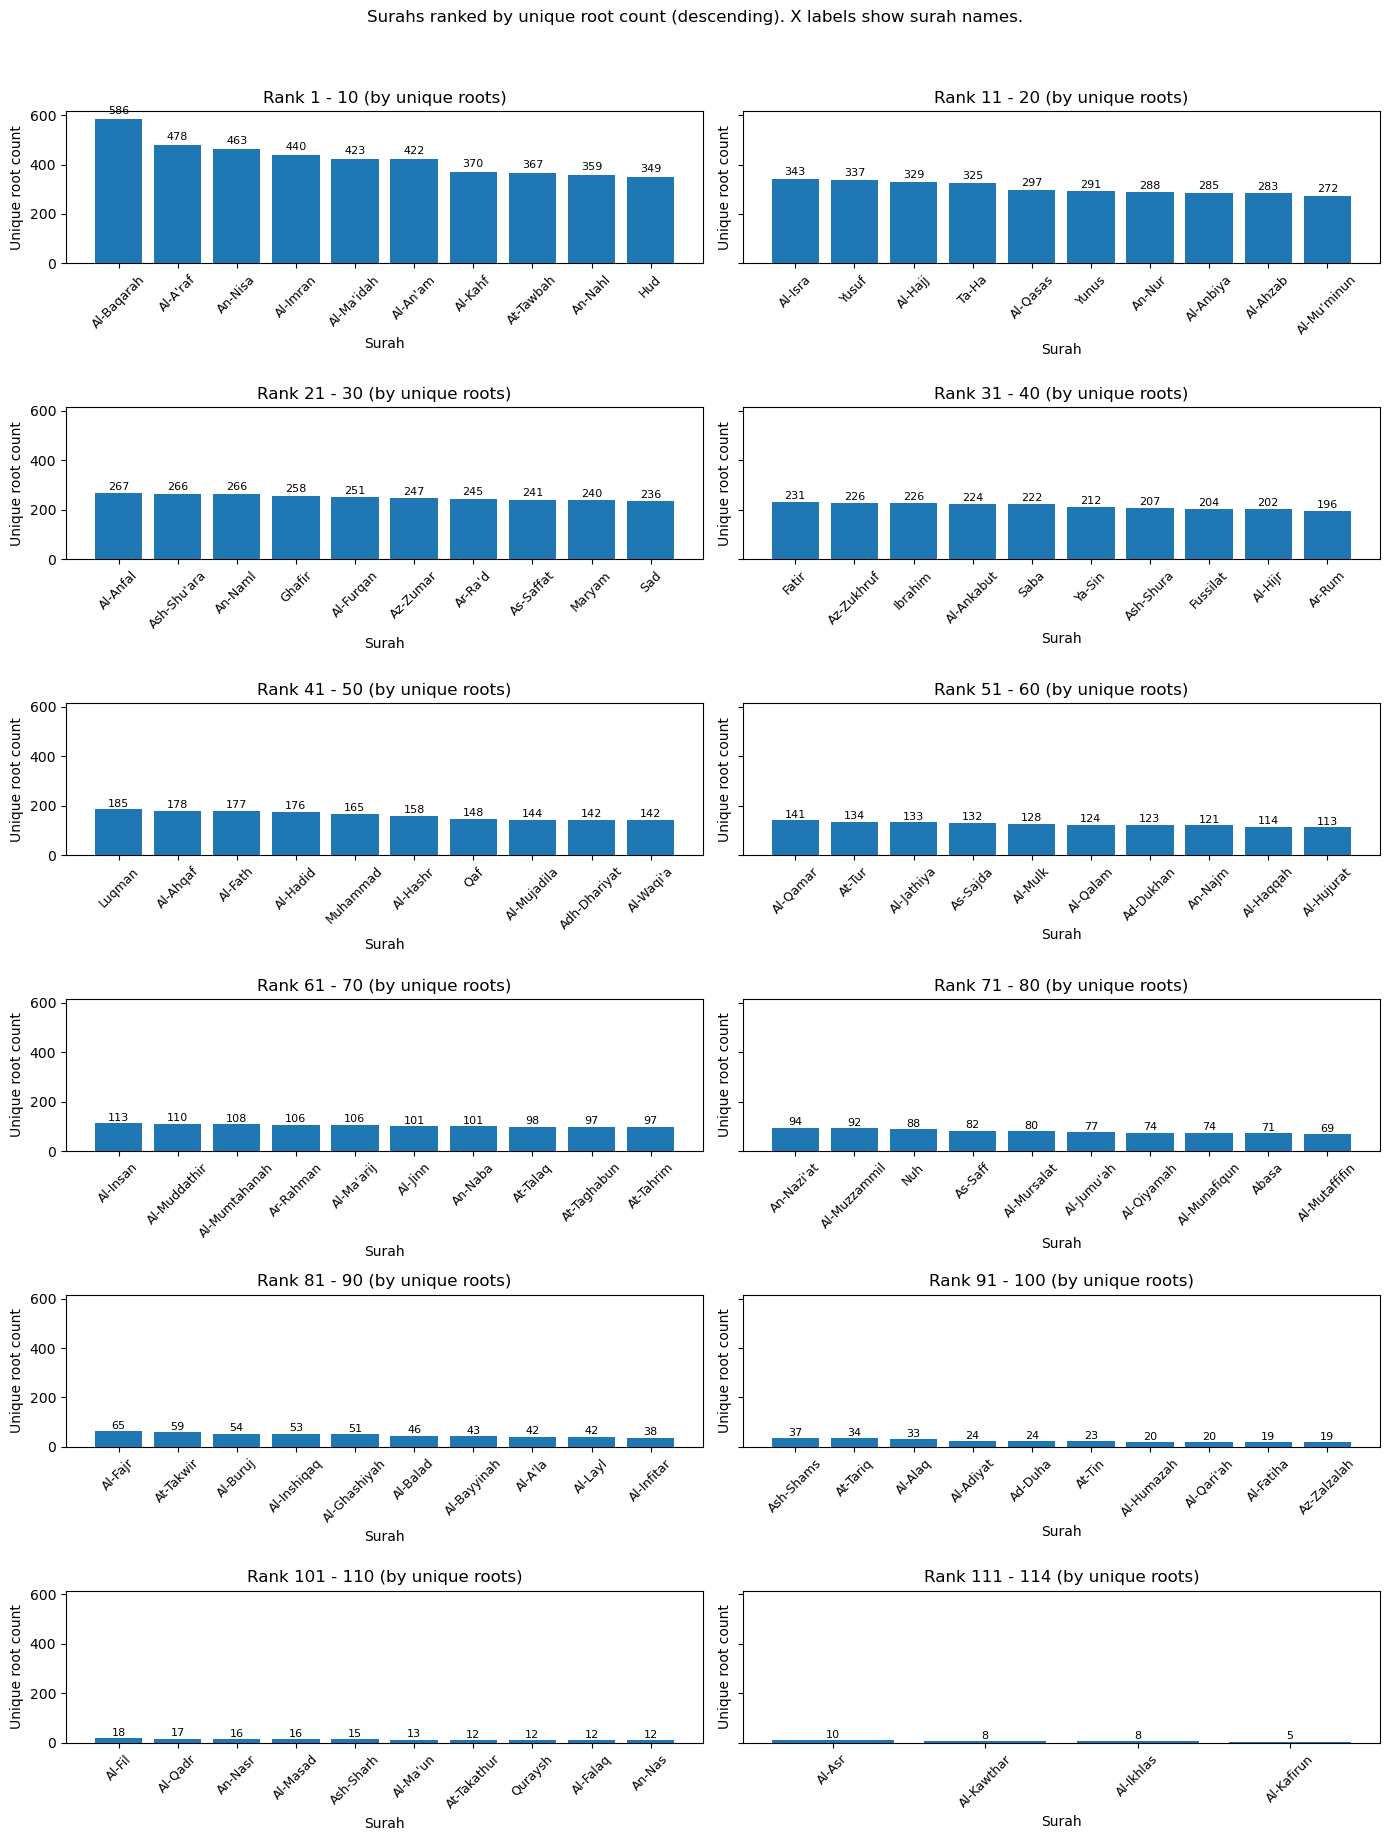

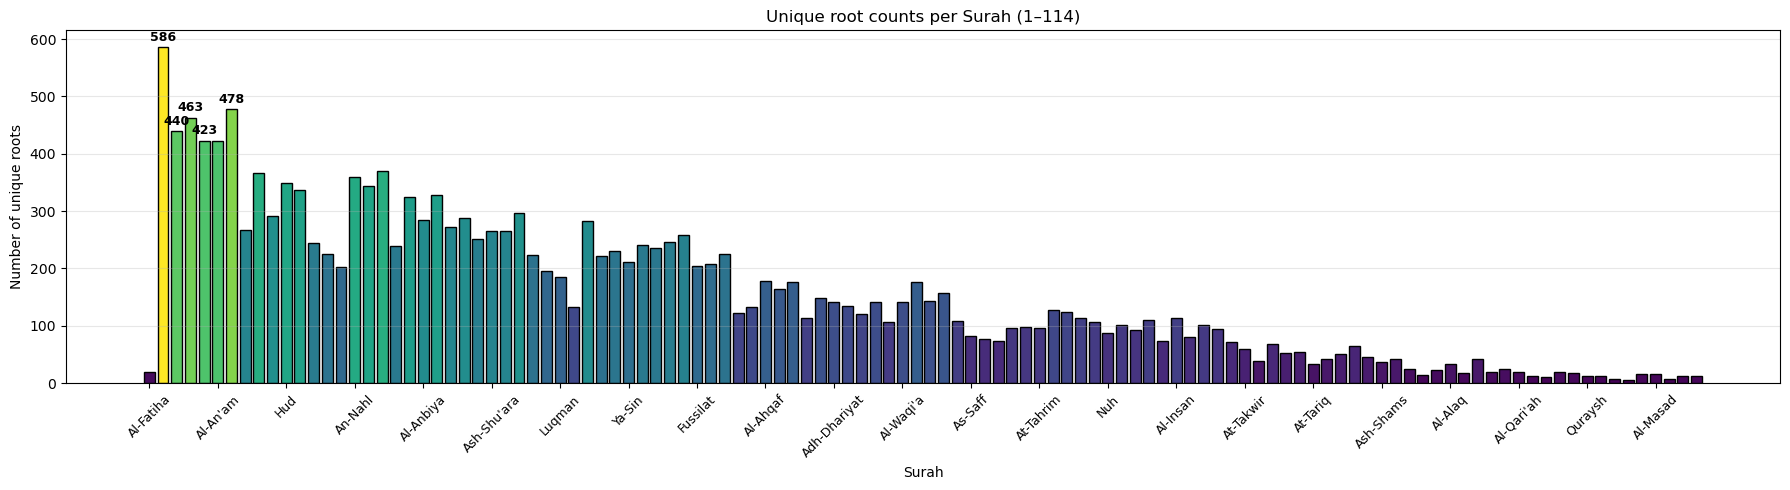

In [7]:
# Use surah_name_to_id to build reverse mapping id -> name
id_to_surah_name = {v: k for k, v in surah_name_en_to_id.items()}

# Rank surahs by unique_root_count and plot in multiple subplots (10 per plot)
df_sorted = df_surah_root_counts.sort_values('unique_root_count', ascending=False).reset_index(drop=True)

group_size = 10
groups = [df_sorted.iloc[i:i+group_size] for i in range(0, len(df_sorted), group_size)]
n_groups = len(groups)

cols = 2
rows = int(np.ceil(n_groups / cols))
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3), sharey=True)
axes = axes.flatten()

for i, grp in enumerate(groups):
    ax = axes[i]
    x = range(len(grp))
    y = grp['unique_root_count'].values
    surah_nums = grp['surah'].astype(int).values
    surah_labels = [id_to_surah_name.get(int(s), str(int(s))) for s in surah_nums]  # use names

    ax.bar(x, y, color='C0')
    ax.set_xticks(x)
    ax.set_xticklabels(surah_labels, rotation=45, fontsize=9)
    start_rank = i * group_size + 1
    end_rank = start_rank + len(grp) - 1
    ax.set_title(f"Rank {start_rank} - {end_rank} (by unique roots)")
    ax.set_xlabel("Surah")
    ax.set_ylabel("Unique root count")
    # annotate bar values
    for xi, yi in zip(x, y):
        ax.text(xi, yi + max(y) * 0.02, str(int(yi)), ha='center', va='bottom', fontsize=8)

# turn off any extra axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Surahs ranked by unique root count (descending). X labels show surah names.", y=1.02)
plt.tight_layout()
plt.show()

# plot unique root counts with surah name labels on selective ticks to keep readability
df_plot = df_surah_root_counts.sort_values('surah').copy()
x = df_plot['surah'].astype(int)
y = df_plot['unique_root_count'].astype(int)

plt.figure(figsize=(18, 5))
cmap = plt.get_cmap('viridis')
colors = cmap((y - y.min()) / (y.max() - y.min()))
plt.bar(x, y, color=colors, edgecolor='k')

plt.title('Unique root counts per Surah (1–114)')
plt.xlabel('Surah')
plt.ylabel('Number of unique roots')
plt.grid(axis='y', alpha=0.3)

# show x-ticks every 5 surahs with surah names to avoid crowding
tick_positions = list(range(1, 115, 5))
tick_labels = [id_to_surah_name.get(i, str(i)) for i in tick_positions]
plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=45, fontsize=9)

# annotate top 5 surahs with highest unique_root_count
top5 = df_plot.nlargest(5, 'unique_root_count')
for _, row in top5.iterrows():
    sx = int(row['surah'])
    sy = int(row['unique_root_count'])
    plt.text(sx, sy + max(y)*0.01, str(sy), ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

## Word level aggregiation for the linguistic set

In [8]:
# What is Implicit Pronoun ?
df_linguistic[df_linguistic['word_id'] == 0].sample(5)

,tid,sentence_id,sentence_word,token_id,location,chapter_id,verse_id,word_id,tok_id,uthmani_token,...,person,gender,number,rel_label,rel_label_ar,ref_token_id,is_constituent,constituents_loc,constituents,constituent_label
105499,105499,8733,0,3,_,38,26,0,1,(أَنْتَ),...,_,_,_,Subj,فاعل,2,0,_,_,_
113066,113066,9341,0,2,_,42,36,0,1,(*),...,_,_,_,sub,صلة,1,1,[2-5],(*) عند الله خيْر,VS
113677,113677,9397,0,0,_,43,11,0,1,(هُوَ),...,_,_,_,root,root,0,-1,_,_,_
8697,8697,721,0,4,_,2,239,0,1,(هُوَ),...,_,_,_,Subj,فاعل,2,0,_,_,-
67650,67650,5596,0,2,_,17,111,0,1,(أَنْتَ),...,_,_,_,Subj,فاعل,1,0,_,_,_


In [9]:
def process_quranic_data(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Process raw Quranic data by removing noise:
    - Implicit pronouns (word_id = 0)
    
    Args:
        raw_df: Raw data from load_raw_quranic_data()
    
    Returns:
        Cleaned DataFrame
    """
    print("🧹 Processing Quranic data...")
    
    initial_count = len(raw_df)
    
    # Step 1: Remove implicit pronouns
    df = raw_df[raw_df['word_id'] > 0].copy()
    removed_pronouns = initial_count - len(df)
 
    
    print(f"   ✅ Removed {removed_pronouns:,} implicit pronouns")

    print(f"   📊 Remaining tokens: {len(df):,}")
    
    return df.reset_index(drop=True)

# Clean data
df_linguistic_proc = process_quranic_data(df_linguistic)

🧹 Processing Quranic data...
   ✅ Removed 11,157 implicit pronouns
   📊 Remaining tokens: 128,219


In [10]:
def get_word_root(series):
    """
    Pick the first real root for a word from its token roots.

    Prefer:
      1) any valid root that is NOT the placeholder 'ـ'
      2) otherwise fall back to 'ـ' if present
      3) else None
    """
    vals = []
    for r in series:
        if pd.isna(r):
            continue
        r = str(r).strip()
        if not r or r == "-":
            continue
        vals.append(r)

    # prefer actual roots over placeholders
    for r in vals:
        if r != "ـ":
            return r

    # fallback: keep placeholder if that's all we have
    return "ـ" if "ـ" in vals else None

def create_word_level_dataframe(cleaned_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate tokens into word-level entries.

    For each (chapter, verse, word) group:
    - Concatenate tokens without spaces (proper Arabic writing)
    - Keep first occurrence of morphological features (root, lemma, pos, trans)
    
    Args:
        cleaned_df: Cleaned data
    
    Returns:
        Word-level DataFrame with columns:
        - chapter_id, verse_id, word_id
        - word_text: Complete word in Uthmanic script
        - root_ar: Arabic root
        - lemma_ar: Lemma form
        - trans: English translation
        - pos: Part-of-speech tag
    """
    print("🔤 Aggregating tokens to word level...")
    
    # word_level = (
    #     cleaned_df.groupby(['chapter_id', 'verse_id', 'word_id'], sort=True)
    #     .agg({
    #         'uthmani_token': lambda x: ''.join(x.astype(str)),  # Concatenate without spaces
    #         'root_ar':       'last',  # Morphological features (first occurrence)
    #         'lemma_ar':      'first',
    #         'trans':         'first',
    #         'pos':           'first',
    #     })
    #     .reset_index()
    #     .rename(columns={'uthmani_token': 'word_text'})
    # )

    word_level_sentence = (
    cleaned_df
    .groupby(["chapter_id", "verse_id", "word_id", "sentence_word"], sort=True)
    .agg({
        "uthmani_token": lambda x: "".join(x.astype(str)),
        "root_ar": get_word_root,
        "lemma_ar": get_word_root,
        "trans": "first",
        "pos": "first",
    })
    .reset_index()
    .rename(columns={"uthmani_token": "word_text"})
    )
        
    return word_level_sentence

# word_level = create_word_level_dataframe(df_linguistic_proc)

In [11]:
# def get_word_root(series):
#     """
#     Pick the first real root for a word from its token roots.

#     Prefer:
#       1) any valid root that is NOT the placeholder 'ـ'
#       2) otherwise fall back to 'ـ' if present
#       3) else None
#     """
#     vals = []
#     for r in series:
#         if pd.isna(r):
#             continue
#         r = str(r).strip()
#         if not r or r == "-":
#             continue
#         vals.append(r)

#     # prefer actual roots over placeholders
#     for r in vals:
#         if r != "ـ":
#             return r

#     # fallback: keep placeholder if that's all we have
#     return "ـ" if "ـ" in vals else None


# word_level_sentence = (
#     df_linguistic_proc
#     .groupby(["chapter_id", "verse_id", "word_id", "sentence_word"], sort=True)
#     .agg({
#         "uthmani_token": lambda x: "".join(x.astype(str)),
#         "root_ar": get_word_root,
#         "lemma_ar": "first",
#         "trans": "first",
#         "pos": "first",
#     })
#     .reset_index()
#     .rename(columns={"uthmani_token": "word_text", "root_ar": "root_ar_word"})
# )

# display(word_level_sentence.head(rows))

In [12]:
word_level = create_word_level_dataframe(df_linguistic_proc)
word_level.sample(10)

🔤 Aggregating tokens to word level...


,chapter_id,verse_id,word_id,sentence_word,word_text,root_ar,lemma_ar,trans,pos
35576,16,99,5,5,على,ـ,عَلَىٰ,on,P
27123,10,45,10,10,يتعارفُون,عرف,يَتَعَارَفُ,they will recognize each other,V
27700,10,83,12,12,وملإيهمْ,ملا,مَلَأ,_,CONJ
66444,48,29,41,10,الزُراع,زرع,زُّرَّاع,_,DET
6892,3,43,7,6,ٱلرَّٰكِعِينَ,ركع,رَاكِع,_,DET
62383,42,13,37,8,من,ـ,مَن,whoever,REL
38345,18,50,16,1,أفتتخذُونهُ,اخذ,ٱتَّخَذَ,_,INTG
10732,4,46,22,3,قَالُوا۟,قول,قَالَ,"(had) said,",V
41420,20,135,10,10,ومن,ـ,مَن,_,CONJ
77392,112,3,1,1,لَمْ,ـ,لَم,Not,NEG


In [13]:
print(f"\n📋 Word-level DataFrame sample:")
display(word_level.sample(5))


📋 Word-level DataFrame sample:


,chapter_id,verse_id,word_id,sentence_word,word_text,root_ar,lemma_ar,trans,pos
76607,90,15,2,10,ذَا,ـ,ذَا,of,N
10948,4,58,18,10,نِعِمَّا,نعم,نِعْمَ,excellently,V
67760,52,38,3,3,سُلم,سلم,سُلَّم,"(is) a stairway,",N
69472,57,12,9,12,وبأيْمنهم,يمن,يَمِين,_,CONJ
2235,2,126,10,10,أَهْلَهُۥ,اهل,أَهْل,its people,N


In [14]:
len(word_level) # 77,430 words in the Quran 

77444

## Verse level aggregiation

In [15]:
def create_verse_level_dataframe(word_df: pd.DataFrame, surah_names: Dict[int, str]) -> pd.DataFrame:
    """
    Aggregate words into verse-level entries.
    
    For each (chapter, verse) group:
    - Join words with spaces to form complete verse text
    - Aggregate translations
    - Add metadata (surah name, reference)
    
    Args:
        word_df: Word-level DataFrame
        surah_names: Dictionary mapping chapter_id to Arabic surah name
    
    Returns:
        Verse-level DataFrame with columns:
        - chapter_id, verse_id
        - verse_text: Complete verse in Uthmanic script
        - verse_trans: Aggregated English translation
        - surah_name, ref
    """
    print("📖 Aggregating words to verse level...")
    
    # Verse text: join words with spaces
    verse_text_df = (
        word_df.groupby(['chapter_id', 'verse_id'])['word_text']
        .apply(lambda x: ' '.join(x.astype(str)))
        .reset_index()
        .rename(columns={'word_text': 'verse_text'})
    )
    
    # Verse translation: join unique translation words, skip blanks/underscores
    def join_trans(x):
        parts = x.dropna().astype(str)
        parts = parts[(parts.str.strip() != '_') & (parts.str.strip() != '')]
        return ' '.join(parts.unique())
    
    verse_trans_df = (
        word_df.groupby(['chapter_id', 'verse_id'])['trans']
        .apply(join_trans)
        .reset_index()
        .rename(columns={'trans': 'verse_trans'})
    )
    
    # Merge and add metadata
    verses = verse_text_df.merge(verse_trans_df, on=['chapter_id', 'verse_id'])
    verses['surah_name'] = verses['chapter_id'].map(surah_names)
    verses['ref'] = verses.apply(
        lambda r: f"{r['surah_name']} ({r['chapter_id']}:{r['verse_id']})", axis=1
    )
    
    print(f"   ✅ Created {len(verses):,} verses from {len(word_df):,} words")
    
    return verses


In [16]:
verses = create_verse_level_dataframe(word_level, surah_name_ar_to_id)
print(f"\n📋 Verse-level DataFrame sample:")
display(verses.sample(5))

📖 Aggregating words to verse level...
   ✅ Created 6,236 verses from 77,444 words

📋 Verse-level DataFrame sample:
   ✅ Created 6,236 verses from 77,444 words

📋 Verse-level DataFrame sample:


,chapter_id,verse_id,verse_text,verse_trans,surah_name,ref
4645,50,16,ولقدْ خلقْنا الْإنسن ونعْلمُ ما تُوسْوسُ به نف...,"We created what whispers his soul, (are) neare...",ق,ق (50:16)
2093,17,65,إن عبادى ليْس لك عليْهمْ سُلْطن وكفى بربك وكيلًا,"""Indeed, My slaves not over them any authority...",الإسراء,الإسراء (17:65)
1008,7,55,ٱدْعُوا۟ رَبَّكُمْ تَضَرُّعًا وَخُفْيَةً إِنَّ...,"Call upon your Lord humbly Indeed, He (does) n...",الأعراف,الأعراف (7:55)
4951,55,51,فبأى ءالاء ربكُما تُكذبان,(of the) favors (of) your Lord will you both d...,الرحمن,الرحمن (55:51)
5662,77,41,إِنَّ ٱلْمُتَّقِينَ فِى ظِلَٰلٍ وَعُيُونٍ,"Indeed, (will be) in shades",المرسلات,المرسلات (77:41)


## Arabic Normalization for Linguistic Search

In [17]:
def normalize_arabic(text: str) -> str:
    """
    Comprehensive Arabic normalization for fuzzy matching.
    
    Steps:
    1. Remove tashkeel (diacritical marks: fatha, damma, kasra, sukun, etc.)
    2. Remove tatweel (kashida/elongation: ـــ)
    3. Remove zero-width and non-printing characters
    4. Unify character variants:
       - All alef variants (إ, أ, آ, ٱ) → ا
       - Taa marbuta (ة) → ha (ه)
       - Alef maqsura (ى) → ya (ي)
       - Waw hamza (ؤ) → waw (و)
       - Ya hamza (ئ) → ya (ي)
    
    This allows matching:
    - رَحِيم (with diacritics) == رحيم (without)
    - الرّحمن == الرحمن
    - إمام == امام
    
    Args:
        text: Arabic text string (or any convertible type)
    
    Returns:
        Normalized Arabic text suitable for fuzzy matching
    """
    if not isinstance(text, str):
        text = str(text)
    
    # Remove tashkeel (harakat)
    # Unicode ranges:
    # U+064B–U+065F: Arabic diacritics
    # U+0670, U+06D6–U+06DC, U+06DF–U+06E4, U+06E7–U+06E8, U+06EA–U+06ED: Extended marks
    text = re.sub(r"[\u064B-\u065F\u0670\u06D6-\u06DC\u06DF-\u06E4\u06E7\u06E8\u06EA-\u06ED]", "", text)
    
    # Remove tatweel (kashida/elongation)
    text = re.sub(r"\u0640", "", text)
    
    # Remove zero-width and non-printing characters
    text = re.sub(r"[\u200B-\u200F\u202A-\u202E\u2060\uFEFF]", "", text)
    
    # Unify character variants
    text = re.sub(r"[إأآٱا]", "ا", text)  # All alef variants → ا
    text = re.sub(r"ة", "ه", text)        # Taa marbuta → ha
    text = re.sub(r"ى", "ي", text)        # Alef maqsura → ya
    text = re.sub(r"ؤ", "و", text)        # Waw hamza → waw
    text = re.sub(r"ئ", "ي", text)        # Ya hamza → ya
    
    return text.strip()


In [18]:
print("\n🧪 Normalization Examples:")
print("=" * 60)

test_cases = [
    "رَحِيم",           # With diacritics
    "الرَّحْمَٰنِ",      # With extended marks
    "إِمَام",          # Hamza variations
    "رؤية",           # Waw hamza
    "مؤمن",           # Waw hamza
    "بئس",            # Ya hamza
    "الـــلـــه",        # With tatweel
    "القرآن",         # Normal text
]

for text in test_cases:
    normalized = normalize_arabic(text)
    print(f"   {text:15} ⬅️ {normalized}")


🧪 Normalization Examples:
   رَحِيم          ⬅️ رحيم
   الرَّحْمَٰنِ    ⬅️ الرحمن
   إِمَام          ⬅️ امام
   رؤية            ⬅️ رويه
   مؤمن            ⬅️ مومن
   بئس             ⬅️ بيس
   الـــلـــه      ⬅️ الله
   القرآن          ⬅️ القران


# Lemma and Root extraction with CAMel tools

In [19]:
from functools import lru_cache

@lru_cache(maxsize=20000)
def get_lemma(word: str) -> str:
    if not isinstance(word, str) or not word.strip():
        return ""
    
    analyses = analyzer.analyze(word)
    
    if not analyses:
        return normalize_arabic(word)
    
    # Prefer best-quality analyses
    for a in analyses:
        lemma = a.get("lex")
        if lemma and lemma != "NOAN":
            return normalize_arabic(lemma)
    
    # fallback
    return normalize_arabic(word)

In [20]:
# example usage
test_words = ["يكتبون", "رَحِيم", "إِمَام", "الـــلـــه", "بئس", "المؤمن", "رؤية"]
print("\n🧪 Lemma Extraction Examples:")
print("=" * 60)
for w in test_words:
    lemma = get_lemma(w)
    print(f"   {w:15} ⬅️ {lemma}")


🧪 Lemma Extraction Examples:
   يكتبون          ⬅️ كتب
   رَحِيم          ⬅️ رحيم
   إِمَام          ⬅️ امام
   الـــلـــه      ⬅️ الله
   بئس             ⬅️ بيس
   المؤمن          ⬅️ مومن
   رؤية            ⬅️ رويه


In [21]:
@lru_cache(maxsize=20000)
def get_root(word: str) -> str:
    if not isinstance(word, str) or not word.strip():
        return ""
    
    analyses = analyzer.analyze(word)
    
    if not analyses:
        return normalize_arabic(word)
    
    for a in analyses:
        root = a.get("root")
        if root and root != "NOAN":
            return normalize_arabic(root)
    
    return normalize_arabic(word)


In [22]:
# Example use
test_words = ["يكتبون", "رَحِيم", "إِمَام", "الـــلـــه", "بئس", "المؤمن", "رؤية"]
print("\n🧪 Root Extraction Examples:")
print("=" * 60)
for w in test_words:
    root = get_root(w)
    print(f"   {w:15} ⬅️ {root}")


🧪 Root Extraction Examples:
   يكتبون          ⬅️ ك.ت.ب
   رَحِيم          ⬅️ ر.ح.م
   إِمَام          ⬅️ #.م.م
   الـــلـــه      ⬅️ #.ل.ه
   بئس             ⬅️ ب.#.س
   المؤمن          ⬅️ #.م.ن
   رؤية            ⬅️ ر.#.#


PySarf performs root extraction, morphological pattern identification, segmentation, and stemming for Arabic text. It uses a rule-based hypothesis-and-rank algorithm with vectorized NumPy batch processing -- no ML models, no Java dependencies, no subprocess calls.

- Root extraction -- derive the trilateral/quadrilateral root from any Arabic word
- Pattern identification -- identify the morphological pattern (wazn/وزن) of a word
- Segmentation -- split words into prefixes + stem + suffixes
- Stemming -- fast greedy affix removal
- Batch processing -- vectorized NumPy pipeline for processing word lists

```bash
git clone https://github.com/Rashidbm/pysarf.git
cd pysarf
pip install -e ".[dev]"
```


In [23]:
# since CAMel tools failed we will use PySarf 
from pysarf import PySarf

sarf = PySarf()

# Full morphological analysis
result = sarf.analyze("المكتبات")
print(result.root)        # كتب
print(result.pattern)     # مفعل
print(result.stem)        # مكتب
print(result.prefixes)    # ('ال',)
print(result.suffixes)    # ('ات',)
print(result.score)       # 0.85 (confidence 0.0-1.0)

كتب
مفعل
مكتب
('ال',)
('ات',)
0.866


In [24]:
# with PySarf let's rewrite the get_root function
@lru_cache(maxsize=20000)
def get_root_pysarf(word: str) -> str:
    if not isinstance(word, str) or not word.strip():
        return ""
    
    result = sarf.analyze(word)
    
    if result and result.root:
        return normalize_arabic(result.root)
    
    return normalize_arabic(word)

In [25]:
# example usage
# not perfect but better than CAMel tools for root extraction in some cases
# for example the root of إمام is أمم not يمم
test_words = ["يكتبون", "رَحِيم", "إِمَام", "الـــلـــه", "بئس", "المؤمن", "رؤية"]
print("\n🧪 Root Extraction Examples:")
print("=" * 60)
for w in test_words:
    root = get_root_pysarf(w)
    print(f"   {w:15} ⬅️ {root}")



🧪 Root Extraction Examples:
   يكتبون          ⬅️ كتب
   رَحِيم          ⬅️ رحم
   إِمَام          ⬅️ يمم
   الـــلـــه      ⬅️ ءله
   بئس             ⬅️ باس
   المؤمن          ⬅️ امن
   رؤية            ⬅️ راي


# Root/Lemma Based search

## Word based search

In [26]:
def search_by_word(word_level: pd.DataFrame, verses: pd.DataFrame, query: str, match_mode: str = "any", exact: bool = False) -> pd.DataFrame:
    """
    Search Quranic verses by word (كلمة).
    
    Can search for exact word matches or partial word matches within verses.
    Uses normalized text for fuzzy matching.
    
    Args:
        word_level: Word-level DataFrame
        verses: Verse-level DataFrame
        query: Space-separated words or phrase (e.g., "الرحمن الحكيم")
        match_mode: "any" (OR) or "all" (AND)
        exact: If True, match complete words; if False, match substring
    
    Returns:
        DataFrame of matching verses
    """
    # Parse and normalize query words
    words = [w.strip() for w in query.split() if w.strip()]
    if not words:
        return pd.DataFrame()
    norm_words = [normalize_arabic(w) for w in words]
    
    # Create normalized verse text column
    v = verses.copy()
    v["_vn"] = v["verse_text"].apply(normalize_arabic)
    
    # Define matching logic
    def row_ok(vn: str) -> bool:
        if exact:
            # Match exact words (word boundary)
            toks = set(vn.split())
            chk = lambda w: w in toks
        else:
            # Match substring
            chk = lambda w: w in vn
        
        if match_mode == "all":
            return all(chk(w) for w in norm_words)  # AND
        else:
            return any(chk(w) for w in norm_words)  # OR
    
    # Apply filter
    mask = v["_vn"].apply(row_ok)
    return v[mask].drop(columns=["_vn"]).reset_index(drop=True)


In [27]:
# Example search
pd.set_option('display.max_colwidth', None)  # Show full verse text without truncation
query = "مصر"
results = search_by_word(word_level, verses, query, match_mode="all", exact=False)
results

,chapter_id,verse_id,verse_text,verse_trans,surah_name,ref
0,2,61,وَإِذْ قُلْتُمْ يَٰمُوسَىٰ لَن نَّصْبِرَ عَلَىٰ طَعَامٍ وَٰحِدٍ فَٱدْعُ لَنَا رَبَّكَ يُخْرِجْ لَنَا مِمَّا تُنۢبِتُ ٱلْأَرْضُ مِنۢ بَقْلِهَا وَقِثَّآئِهَا وَفُومِهَا وَعَدَسِهَا وَبَصَلِهَا قَالَ أَتَسْتَبْدِلُونَ ٱلَّذِى هُوَ أَدْنَىٰ بِٱلَّذِى هُوَ خَيْرٌ ٱهْبِطُوا۟ مِصْرًا فَإِنَّ لَكُم مَّا سَأَلْتُمْ وَضُرِبَتْ عَلَيْهِمُ ٱلذِّلَّةُ وَٱلْمَسْكَنَةُ وَبَآءُو بِغَضَبٍ مِّنَ ٱللَّهِ ذَٰلِكَ بِأَنَّهُمْ كَانُوا۟ يَكْفُرُونَ بِـَٔايَٰتِ ٱللَّهِ وَيَقْتُلُونَ ٱلنَّبِيِّۦنَ بِغَيْرِ ٱلْحَقِّ ذَٰلِكَ بِمَا عَصَوا۟ وَّكَانُوا۟ يَعْتَدُونَ,"you said, Never (will) we endure [on] food (of) one (kind), (to) your Lord to bring forth out of what grows of its herbs, He said, that which [it] (is) inferior (is) better? Go down (to) a city, (is) what you have asked (for)."" on them Allah That (was) used to disbelieve (of) Allah That they disobeyed transgressing.",البقرة,البقرة (2:61)
1,10,87,وأوْحيْنا إلى مُوسى وأخيه أن تبوءا لقوْمكُما بمصْر بُيُوتًا واجْعلُوا بُيُوتكُمْ قبْلةً وأقيمُوا الصلوة وبشر الْمُؤْمنين,"to Musa that, ""Settle (in) houses, your houses (as) places of worship,",يونس,يونس (10:87)
2,11,8,ولئنْ أخرْنا عنْهُمُ الْعذاب إلى أُمةٍ معْدُودةٍ ليقُولُن ما يحْبسُهُ ألا يوْم يأْتيهمْ ليْس مصْرُوفًا عنْهُمْ وحاق بهم ما كانُوا به يسْتهْزءُون,"We delay from them for a time determined, ""What detains it?"" No doubt! (On) the Day it comes to them not (will be) averted what they used (to) mock at [it].",هود,هود (11:8)
3,12,21,وقال الذى اشْترىهُ من مصْر لامْرأته أكْرمى مثْوىهُ عسى أن ينفعنا أوْ نتخذهُ ولدًا وكذلك مكنا ليُوسُف فى الْأرْض ولنُعلمهُ من تأْويل الْأحاديث واللهُ غالب على أمْره ولكن أكْثر الناس لا يعْلمُون,"the one who bought him of Egypt ""Make comfortable his stay. Perhaps that (he) will benefit us or we will take him (as) a son."" We established in (the) interpretation of (is) Predominant over His affairs, most (do) not know.",يوسف,يوسف (12:21)
4,12,99,فلما دخلُوا على يُوسُف ءاوى إليْه أبويْه وقال ادْخُلُوا مصْر إن شاء اللهُ ءامنين,"they entered upon Yusuf, he took to himself his parents ""Enter Egypt if Allah wills, safe.""",يوسف,يوسف (12:99)
5,14,22,وقال الشيْطنُ لما قُضى الْأمْرُ إن الله وعدكُمْ وعْد الْحق ووعدتُكُمْ فأخْلفْتُكُمْ وما كان لى عليْكُم من سُلْطنٍ إلا أن دعوْتُكُمْ فاسْتجبْتُمْ لى فلا تلُومُونى ولُومُوا أنفُسكُم ما أنا بمُصْرخكُمْ وما أنتُم بمُصْرخىـ إنى كفرْتُ بما أشْركْتُمُون من قبْلُ إن الظلمين لهُمْ عذاب أليم,"when has been decided ""Indeed, Allah promised you a promise I had over you any authority except that I invited you, blame me, yourselves. Not (can) I you (can) Indeed, I deny your association of me (with Allah) before. Indeed, (is) a punishment painful.""",إبراهيم,إبراهيم (14:22)
6,18,53,ورءا الْمُجْرمُون النار فظنُوا أنهُم مُواقعُوها ولمْ يجدُوا عنْها مصْرفًا,that they are to fall in it. they will find from it a way of escape.,الكهف,الكهف (18:53)
7,43,51,ونادى فرْعوْنُ فى قوْمه قال يقوْمـ أليْس لى مُلْكُ مصْر وهذه الْأنْهرُ تجْرى من تحْتى أفلا تُبْصرُون,"Firaun among his people; he said, (the) kingdom (of) Egypt flowing underneath me? you see?",الزخرف,الزخرف (43:51)


In [28]:
# Example search 2 
query2 = "الرحمن الحكيم"
results2 = search_by_word(word_level, verses, query2, match_mode="all", exact=False)
results2

,chapter_id,verse_id,verse_text,verse_trans,surah_name,ref


In [29]:
# Example search 3 
query2 = "الرحمن الحكيم"
results3 = search_by_word(word_level, verses, query2, match_mode="any", exact=False)
results3

,chapter_id,verse_id,verse_text,verse_trans,surah_name,ref
0,1,1,بِسْمِ ٱللَّهِ ٱلرَّحْمَٰنِ ٱلرَّحِيمِ,"(of) Allah,",الفاتحة,الفاتحة (1:1)
1,1,3,ٱلرَّحْمَٰنِ ٱلرَّحِيمِ,,الفاتحة,الفاتحة (1:3)
2,2,32,قَالُوا۟ سُبْحَٰنَكَ لَا عِلْمَ لَنَآ إِلَّا مَا عَلَّمْتَنَآ إِنَّكَ أَنتَ ٱلْعَلِيمُ ٱلْحَكِيمُ,"They said, ""Glory be to You! No knowledge except what You have taught us. Indeed You! You",البقرة,البقرة (2:32)
3,2,129,رَبَّنَا وَٱبْعَثْ فِيهِمْ رَسُولًا مِّنْهُمْ يَتْلُوا۟ عَلَيْهِمْ ءَايَٰتِكَ وَيُعَلِّمُهُمُ ٱلْكِتَٰبَ وَٱلْحِكْمَةَ وَيُزَكِّيهِمْ إِنَّكَ أَنتَ ٱلْعَزِيزُ ٱلْحَكِيمُ,Our Lord! in them a Messenger from them (who) will recite to them Your Verses Indeed You! You (are),البقرة,البقرة (2:129)
4,2,163,وَإِلَٰهُكُمْ إِلَٰهٌ وَٰحِدٌ لَّآ إِلَٰهَ إِلَّا هُوَ ٱلرَّحْمَٰنُ ٱلرَّحِيمُ,"(is) God one (only); (there is) no god except Him,",البقرة,البقرة (2:163)
...,...,...,...,...,...,...
85,67,19,أَوَلَمْ يَرَوْا۟ إِلَى ٱلطَّيْرِ فَوْقَهُمْ صَٰٓفَّٰتٍ وَيَقْبِضْنَ مَا يُمْسِكُهُنَّ إِلَّا ٱلرَّحْمَٰنُ إِنَّهُۥ بِكُلِّ شَىْءٍۭ بَصِيرٌ,"they see [to] above them spreading (their wings) Not holds them except Indeed, He thing All-Seer.",الملك,الملك (67:19)
86,67,20,أَمَّنْ هَٰذَا ٱلَّذِى هُوَ جُندٌ لَّكُمْ يَنصُرُكُم مِّن دُونِ ٱلرَّحْمَٰنِ إِنِ ٱلْكَٰفِرُونَ إِلَّا فِى غُرُورٍ,"Who is this, the one, he (is) an army to help you from besides Not but in delusion.",الملك,الملك (67:20)
87,67,29,قُلْ هُوَ ٱلرَّحْمَٰنُ ءَامَنَّا بِهِۦ وَعَلَيْهِ تَوَكَّلْنَا فَسَتَعْلَمُونَ مَنْ هُوَ فِى ضَلَٰلٍ مُّبِينٍ,"Say, ""He we believe we put (our) trust. who (is) it (that is) in error clear.""",الملك,الملك (67:29)
88,78,37,رَّبِّ ٱلسَّمَٰوَٰتِ وَٱلْأَرْضِ وَمَا بَيْنَهُمَا ٱلرَّحْمَٰنِ لَا يَمْلِكُونَ مِنْهُ خِطَابًا,Lord (is) between both of them not they have power from Him (to) address.,النبأ,النبأ (78:37)


In [30]:
# reset the display option to default
pd.reset_option('display.max_colwidth')

## Lemma based search

In [31]:
get_lemma("كتب")

'كتاب'

In [32]:
get_lemma("يكتبون")

'كتب'

In [33]:
get_lemma("كتاب")

'كتاب'

In [34]:
def search_by_lemma(word_level: pd.DataFrame, verses: pd.DataFrame, query: str, match_mode: str = "any") -> pd.DataFrame:
    """
    Search Quranic verses by lemma (لمّة) — dictionary/base form.
    
    Lemma is the citation form of a word from which inflected forms are derived.
    For example, the lemma for both "يكتب" (he writes) and "كتبت" (I wrote) is "كتب".
    
    Args:
        word_level: Word-level DataFrame
        verses: Verse-level DataFrame
        query: Space-separated lemmas (e.g., "رحم حمد")
        match_mode: "any" (OR) or "all" (AND)
    
    Returns:
        DataFrame of matching verses
    """
    # Parse and normalize query lemmas
    lemmas = [normalize_arabic(l.strip()) for l in query.split() if l.strip()]
    if not lemmas:
        return pd.DataFrame()
    
    # Create normalized lemma column
    wl = word_level.copy()
    wl["_ln"] = wl["lemma_ar"].apply(lambda x: normalize_arabic(x) if pd.notna(x) else "")
    
    # Find words with matching lemmas
    hits = wl[wl["_ln"].isin(lemmas)]
    
    # Filter verses based on match_mode
    def verse_ok(g):
        found = set(g["_ln"].unique())
        if match_mode == "all":
            return all(l in found for l in lemmas)  # AND
        else:
            return any(l in found for l in lemmas)  # OR
    
    # Get unique verses meeting criteria
    keys = (
        hits.groupby(["chapter_id", "verse_id"])
        .filter(verse_ok)[["chapter_id", "verse_id"]]
        .drop_duplicates()
    )
    
    # Merge with complete verse data
    return keys.merge(verses, on=["chapter_id", "verse_id"]).reset_index(drop=True)


In [35]:
# Example search
query = "مصر"
results = search_by_lemma(word_level, verses, query, match_mode="any")
results

,chapter_id,verse_id,verse_text,verse_trans,surah_name,ref
0,2,61,وَإِذْ قُلْتُمْ يَٰمُوسَىٰ لَن نَّصْبِرَ عَلَى...,"you said, Never (will) we endure [on] food (of...",البقرة,البقرة (2:61)
1,10,87,وأوْحيْنا إلى مُوسى وأخيه أن تبوءا لقوْمكُما ب...,"to Musa that, ""Settle (in) houses, your houses...",يونس,يونس (10:87)
2,12,21,وقال الذى اشْترىهُ من مصْر لامْرأته أكْرمى مثْ...,"the one who bought him of Egypt ""Make comforta...",يوسف,يوسف (12:21)
3,12,99,فلما دخلُوا على يُوسُف ءاوى إليْه أبويْه وقال ...,"they entered upon Yusuf, he took to himself hi...",يوسف,يوسف (12:99)
4,43,51,ونادى فرْعوْنُ فى قوْمه قال يقوْمـ أليْس لى مُ...,"Firaun among his people; he said, (the) kingdo...",الزخرف,الزخرف (43:51)


In [36]:
query2 = "كتب"
results = search_by_lemma(word_level, verses, query2, match_mode="any")
results

,chapter_id,verse_id,verse_text,verse_trans,surah_name,ref
0,2,2,ذَٰلِكَ ٱلْكِتَٰبُ لَا رَيْبَ فِيهِ هُدًى لِّل...,"That no doubt in it, a Guidance",البقرة,البقرة (2:2)
1,2,44,أَتَأْمُرُونَ ٱلنَّاسَ بِٱلْبِرِّ وَتَنسَوْنَ ...,"yourselves, [you] recite you use reason?",البقرة,البقرة (2:44)
2,2,53,وَإِذْ ءَاتَيْنَا مُوسَى ٱلْكِتَٰبَ وَٱلْفُرْق...,We gave Musa perhaps you (would be) guided.,البقرة,البقرة (2:53)
3,2,78,وَمِنْهُمْ أُمِّيُّونَ لَا يَعْلَمُونَ ٱلْكِتَ...,"(are) unlettered ones, (who) do not know excep...",البقرة,البقرة (2:78)
4,2,79,فَوَيْلٌ لِّلَّذِينَ يَكْتُبُونَ ٱلْكِتَٰبَ بِ...,"write then, they say, ""This (is) from Allah,"" ...",البقرة,البقرة (2:79)
...,...,...,...,...,...,...
268,84,10,وَأَمَّا مَنْ أُوتِىَ كِتَٰبَهُۥ وَرَآءَ ظَهْ...,"(him) who is given his record behind his back,",الانشقاق,الانشقاق (84:10)
269,98,1,لَمْ يَكُنِ ٱلَّذِينَ كَفَرُوا۟ مِنْ أَهْلِ ٱل...,Not were those who disbelieved from (the) Peop...,البينة,البينة (98:1)
270,98,3,فِيهَا كُتُبٌ قَيِّمَةٌ,Wherein (are) writings correct.,البينة,البينة (98:3)
271,98,4,وَمَا تَفَرَّقَ ٱلَّذِينَ أُوتُوا۟ ٱلْكِتَٰبَ ...,became divided those who were given until from...,البينة,البينة (98:4)


In [37]:
query2 = "يكتبون"
results = search_by_lemma(word_level, verses, query2, match_mode="any")
results

,chapter_id,verse_id,verse_text,verse_trans,surah_name,ref


## Root based search

In [38]:
def search_by_root(
    word_level: pd.DataFrame,
    verses: pd.DataFrame,
    query: str,
    match_mode: str = "any",
    use_pysarf_on_query: bool = True,
) -> pd.DataFrame:
    """
    Search Quranic verses by triliteral root (جذر) using the already-annotated `root_ar`
    column in `word_level`.

    This function keeps the dataset-side logic unchanged:
    - It **does not** re-extract roots for the full corpus.
    - It matches against `word_level["root_ar"]` after applying `normalize_arabic`.

    Optional enhancement (query-side only):
    - If `use_pysarf_on_query=True`, the query terms are first passed through
      `get_root_pysarf()` to derive their roots, then normalized. This helps when the
      user provides an inflected form (e.g., "الأرض") and wants to search by its root.
    - If `use_pysarf_on_query=False`, query terms are only normalized (no root extraction).

    Parameters
    ----------
    word_level : pd.DataFrame
        Word-level dataframe with at least:
        - `chapter_id`, `verse_id` (to identify verses)
        - `root_ar` (root annotations per word/token group)

    verses : pd.DataFrame
        Verse-level dataframe with at least:
        - `chapter_id`, `verse_id`
        plus any additional columns you want returned (e.g., `verse_text`, `ref`, etc.).

    query : str
        Space-separated query terms. Terms can be:
        - roots directly (e.g., "كتب")
        - surface forms to be root-extracted (e.g., "يكتبون") when `use_pysarf_on_query=True`.

    match_mode : str, default "any"
        Verse filtering mode:
        - "any": a verse matches if it contains **at least one** of the query roots (OR)
        - "all": a verse matches only if it contains **all** query roots (AND)

    use_pysarf_on_query : bool, default True
        If True, apply `get_root_pysarf()` to each query term before matching.
        If False, match using normalized query terms as provided.

    Returns
    -------
    pd.DataFrame
        Subset of `verses` containing only matching verses. The result is merged by
        (`chapter_id`, `verse_id`), and the index is reset.

    Notes
    -----
    - The temporary helper column `_rn` is created on a copy of `word_level` and is used
      only for matching; it is not returned.
    - Normalization is applied to:
      - dataset roots (`root_ar`) via `normalize_arabic`
      - query terms either via `get_root_pysarf` (which also normalizes) or directly
        via `normalize_arabic`
    """
    # Parse query
    terms = [r.strip() for r in str(query).split() if r.strip()]
    if not terms:
        return pd.DataFrame()

    # Normalize / root-extract only the query terms (do not touch the main flow)
    if use_pysarf_on_query:
        norm_roots = [get_root_pysarf(t) for t in terms]
    else:
        norm_roots = [normalize_arabic(t) for t in terms]

    # Create normalized root column from dataset roots (same as before)
    wl = word_level.copy()
    wl["_rn"] = wl["root_ar"].apply(lambda x: normalize_arabic(x) if pd.notna(x) else "")


    # Find words with matching roots
    hits = wl[wl["_rn"].isin(norm_roots)]

    # Filter verses based on match_mode
    def verse_ok(g):
        found = set(g["_rn"].unique())
        if match_mode == "all":
            return all(r in found for r in norm_roots)
        return any(r in found for r in norm_roots)

    keys = (
        hits.groupby(["chapter_id", "verse_id"])
        .filter(verse_ok)[["chapter_id", "verse_id"]]
        .drop_duplicates()
    )

    return keys.merge(verses, on=["chapter_id", "verse_id"]).reset_index(drop=True)


In [39]:
# Example search
query = "يكتبون"
results = search_by_root(word_level, verses, query, match_mode="any")
results

,chapter_id,verse_id,verse_text,verse_trans,surah_name,ref
0,2,2,ذَٰلِكَ ٱلْكِتَٰبُ لَا رَيْبَ فِيهِ هُدًى لِّل...,"That no doubt in it, a Guidance",البقرة,البقرة (2:2)
1,2,44,أَتَأْمُرُونَ ٱلنَّاسَ بِٱلْبِرِّ وَتَنسَوْنَ ...,"yourselves, [you] recite you use reason?",البقرة,البقرة (2:44)
2,2,53,وَإِذْ ءَاتَيْنَا مُوسَى ٱلْكِتَٰبَ وَٱلْفُرْق...,We gave Musa perhaps you (would be) guided.,البقرة,البقرة (2:53)
3,2,78,وَمِنْهُمْ أُمِّيُّونَ لَا يَعْلَمُونَ ٱلْكِتَ...,"(are) unlettered ones, (who) do not know excep...",البقرة,البقرة (2:78)
4,2,79,فَوَيْلٌ لِّلَّذِينَ يَكْتُبُونَ ٱلْكِتَٰبَ بِ...,"write then, they say, ""This (is) from Allah,"" ...",البقرة,البقرة (2:79)
...,...,...,...,...,...,...
274,84,10,وَأَمَّا مَنْ أُوتِىَ كِتَٰبَهُۥ وَرَآءَ ظَهْ...,"(him) who is given his record behind his back,",الانشقاق,الانشقاق (84:10)
275,98,1,لَمْ يَكُنِ ٱلَّذِينَ كَفَرُوا۟ مِنْ أَهْلِ ٱل...,Not were those who disbelieved from (the) Peop...,البينة,البينة (98:1)
276,98,3,فِيهَا كُتُبٌ قَيِّمَةٌ,Wherein (are) writings correct.,البينة,البينة (98:3)
277,98,4,وَمَا تَفَرَّقَ ٱلَّذِينَ أُوتُوا۟ ٱلْكِتَٰبَ ...,became divided those who were given until from...,البينة,البينة (98:4)


In [40]:
# Example search
pd.set_option('display.max_colwidth', None)  # Show full verse text without truncation
query = "الرحمن"
results = search_by_root(word_level, verses, query, match_mode="all")
results

,chapter_id,verse_id,verse_text,verse_trans,surah_name,ref
0,1,1,بِسْمِ ٱللَّهِ ٱلرَّحْمَٰنِ ٱلرَّحِيمِ,"(of) Allah,",الفاتحة,الفاتحة (1:1)
1,1,3,ٱلرَّحْمَٰنِ ٱلرَّحِيمِ,,الفاتحة,الفاتحة (1:3)
2,2,37,فَتَلَقَّىٰٓ ءَادَمُ مِن رَّبِّهِۦ كَلِمَٰتٍ فَتَابَ عَلَيْهِ إِنَّهُۥ هُوَ ٱلتَّوَّابُ ٱلرَّحِيمُ,"Adam from his Lord words, towards him. Indeed He! He",البقرة,البقرة (2:37)
3,2,54,وَإِذْ قَالَ مُوسَىٰ لِقَوْمِهِۦ يَٰقَوْمِ إِنَّكُمْ ظَلَمْتُمْ أَنفُسَكُم بِٱتِّخَاذِكُمُ ٱلْعِجْلَ فَتُوبُوٓا۟ إِلَىٰ بَارِئِكُمْ فَٱقْتُلُوٓا۟ أَنفُسَكُمْ ذَٰلِكُمْ خَيْرٌ لَّكُمْ عِندَ بَارِئِكُمْ فَتَابَ عَلَيْكُمْ إِنَّهُۥ هُوَ ٱلتَّوَّابُ ٱلرَّحِيمُ,"said Musa Indeed, you [you] have wronged yourselves to your Creator, yourselves. That (is) better with your Creator."" towards you. Indeed He! He",البقرة,البقرة (2:54)
4,2,64,ثُمَّ تَوَلَّيْتُم مِّنۢ بَعْدِ ذَٰلِكَ فَلَوْلَا فَضْلُ ٱللَّهِ عَلَيْكُمْ وَرَحْمَتُهُۥ لَكُنتُم مِّنَ ٱلْخَٰسِرِينَ,Then you turned away from after that. (for the) Grace (of) Allah upon you of,البقرة,البقرة (2:64)
...,...,...,...,...,...,...
308,73,20,إِنَّ رَبَّكَ يَعْلَمُ أَنَّكَ تَقُومُ أَدْنَىٰ مِن ثُلُثَىِ ٱلَّيْلِ وَنِصْفَهُۥ وَثُلُثَهُۥ وَطَآئِفَةٌ مِّنَ ٱلَّذِينَ مَعَكَ وَٱللَّهُ يُقَدِّرُ ٱلَّيْلَ وَٱلنَّهَارَ عَلِمَ أَن لَّن تُحْصُوهُ فَتَابَ عَلَيْكُمْ فَٱقْرَءُوا۟ مَا تَيَسَّرَ مِنَ ٱلْقُرْءَانِ عَلِمَ أَن سَيَكُونُ مِنكُم مَّرْضَىٰ وَءَاخَرُونَ يَضْرِبُونَ فِى ٱلْأَرْضِ يَبْتَغُونَ مِن فَضْلِ ٱللَّهِ وَءَاخَرُونَ يُقَٰتِلُونَ فِى سَبِيلِ ٱللَّهِ فَٱقْرَءُوا۟ مَا تَيَسَّرَ مِنْهُ وَأَقِيمُوا۟ ٱلصَّلَوٰةَ وَءَاتُوا۟ ٱلزَّكَوٰةَ وَأَقْرِضُوا۟ ٱللَّهَ قَرْضًا حَسَنًا وَمَا تُقَدِّمُوا۟ لِأَنفُسِكُم مِّنْ خَيْرٍ تَجِدُوهُ عِندَ ٱللَّهِ هُوَ خَيْرًا وَأَعْظَمَ أَجْرًا وَٱسْتَغْفِرُوا۟ ٱللَّهَ إِنَّ ٱللَّهَ غَفُورٌ رَّحِيمٌۢ,"Indeed, your Lord knows that you stand (a little) less than two-thirds of those who (are) with you. determines He knows that not you count it, to you, what is easy among you sick traveling in seeking (the) Bounty (of) Allah, fighting (the) way (of) Allah. of it, Allah a loan goodly. you send forth good, you will find it with Allah. It (will be) better (in) reward. (is) Oft-Forgiving, Most Merciful.",المزمل,المزمل (73:20)
309,76,31,يُدْخِلُ مَن يَشَآءُ فِى رَحْمَتِهِۦ وَٱلظَّٰلِمِينَ أَعَدَّ لَهُمْ عَذَابًا أَلِيمًۢا,"He admits whom He wills into His mercy, He has prepared a punishment painful.",الإنسان,الإنسان (76:31)
310,78,37,رَّبِّ ٱلسَّمَٰوَٰتِ وَٱلْأَرْضِ وَمَا بَيْنَهُمَا ٱلرَّحْمَٰنِ لَا يَمْلِكُونَ مِنْهُ خِطَابًا,Lord (is) between both of them not they have power from Him (to) address.,النبأ,النبأ (78:37)
311,78,38,يَوْمَ يَقُومُ ٱلرُّوحُ وَٱلْمَلَٰٓئِكَةُ صَفًّا لَّا يَتَكَلَّمُونَ إِلَّا مَنْ أَذِنَ لَهُ ٱلرَّحْمَٰنُ وَقَالَ صَوَابًا,"(The) Day will stand (in) rows, not they will speak except (one) who - permits (what is) correct.",النبأ,النبأ (78:38)


In [41]:
# Example search
pd.set_option('display.max_colwidth', None)  # Show full verse text without truncation
query = "كن"
results = search_by_root(word_level, verses, query, match_mode="any")
results

,chapter_id,verse_id,verse_text,verse_trans,surah_name,ref
0,2,10,فِى قُلُوبِهِم مَّرَضٌ فَزَادَهُمُ ٱللَّهُ مَرَضًا وَلَهُمْ عَذَابٌ أَلِيمٌۢ بِمَا كَانُوا۟ يَكْذِبُونَ,"In their hearts (is) a disease, Allah (in) disease; (is) a punishment painful they used to [they] lie.",البقرة,البقرة (2:10)
1,2,16,أُو۟لَٰٓئِكَ ٱلَّذِينَ ٱشْتَرَوُا۟ ٱلضَّلَٰلَةَ بِٱلْهُدَىٰ فَمَا رَبِحَت تِّجَٰرَتُهُمْ وَمَا كَانُوا۟ مُهْتَدِينَ,Those (are) the ones who bought profited their commerce were they guided-ones.,البقرة,البقرة (2:16)
2,2,23,وَإِن كُنتُمْ فِى رَيْبٍ مِّمَّا نَزَّلْنَا عَلَىٰ عَبْدِنَا فَأْتُوا۟ بِسُورَةٍ مِّن مِّثْلِهِۦ وَٱدْعُوا۟ شُهَدَآءَكُم مِّن دُونِ ٱللَّهِ إِن كُنتُمْ صَٰدِقِينَ,"you are in doubt about what We have revealed to Our slave, [of] like it your witnesses from other than Allah if truthful.",البقرة,البقرة (2:23)
3,2,28,كَيْفَ تَكْفُرُونَ بِٱللَّهِ وَكُنتُمْ أَمْوَٰتًا فَأَحْيَٰكُمْ ثُمَّ يُمِيتُكُمْ ثُمَّ يُحْيِيكُمْ ثُمَّ إِلَيْهِ تُرْجَعُونَ,"How (can) you disbelieve dead then He will cause you to die, He will give you life, to Him you will be returned.",البقرة,البقرة (2:28)
4,2,31,وَعَلَّمَ ءَادَمَ ٱلْأَسْمَآءَ كُلَّهَا ثُمَّ عَرَضَهُمْ عَلَى ٱلْمَلَٰٓئِكَةِ فَقَالَ أَنۢبِـُٔونِى بِأَسْمَآءِ هَٰٓؤُلَآءِ إِن كُنتُمْ صَٰدِقِينَ,"Adam all of them. Then He displayed them to ""Inform Me (of) these, if you are truthful.""",البقرة,البقرة (2:31)
...,...,...,...,...,...,...
1171,98,1,لَمْ يَكُنِ ٱلَّذِينَ كَفَرُوا۟ مِنْ أَهْلِ ٱلْكِتَٰبِ وَٱلْمُشْرِكِينَ مُنفَكِّينَ حَتَّىٰ تَأْتِيَهُمُ ٱلْبَيِّنَةُ,Not were those who disbelieved from (the) People to be abandoned until (there) comes to them,البينة,البينة (98:1)
1172,101,4,يَوْمَ يَكُونُ ٱلنَّاسُ كَٱلْفَرَاشِ ٱلْمَبْثُوثِ,(The) Day will be,القارعة,القارعة (101:4)
1173,101,5,وَتَكُونُ ٱلْجِبَالُ كَٱلْعِهْنِ ٱلْمَنفُوشِ,,القارعة,القارعة (101:5)
1174,110,3,فَسَبِّحْ بِحَمْدِ رَبِّكَ وَٱسْتَغْفِرْهُ إِنَّهُۥ كَانَ تَوَّابًۢا,"(of) your Lord Indeed, He is Oft-Returning.",النصر,النصر (110:3)


In [42]:
get_root_pysarf("الأرض")

'ارض'

In [43]:
len(get_root_pysarf("الأرض"))

3

In [44]:
pd.set_option('display.max_colwidth', None)  # Show full verse text without truncation
query = "الأرض"
results = search_by_root(word_level, verses, query, match_mode="all")
display(results, results.shape)

,chapter_id,verse_id,verse_text,verse_trans,surah_name,ref
0,2,11,وَإِذَا قِيلَ لَهُمْ لَا تُفْسِدُوا۟ فِى ٱلْأَرْضِ قَالُوٓا۟ إِنَّمَا نَحْنُ مُصْلِحُونَ,"it is said ""(Do) not spread corruption in they say, ""Only we (are) reformers.""",البقرة,البقرة (2:11)
1,2,22,ٱلَّذِى جَعَلَ لَكُمُ ٱلْأَرْضَ فِرَٰشًا وَٱلسَّمَآءَ بِنَآءً وَأَنزَلَ مِنَ ٱلسَّمَآءِ مَآءً فَأَخْرَجَ بِهِۦ مِنَ ٱلثَّمَرَٰتِ رِزْقًا لَّكُمْ فَلَا تَجْعَلُوا۟ لِلَّهِ أَندَادًا وَأَنتُمْ تَعْلَمُونَ,"The One Who made a resting place a canopy, from water, [of] (as) provision set up rivals [you] know.",البقرة,البقرة (2:22)
2,2,27,ٱلَّذِينَ يَنقُضُونَ عَهْدَ ٱللَّهِ مِنۢ بَعْدِ مِيثَٰقِهِۦ وَيَقْطَعُونَ مَآ أَمَرَ ٱللَّهُ بِهِۦٓ أَن يُوصَلَ وَيُفْسِدُونَ فِى ٱلْأَرْضِ أُو۟لَٰٓئِكَ هُمُ ٱلْخَٰسِرُونَ,"Those who break (the) Covenant (of) Allah from after its ratification, what has ordered Allah to be joined in Those, they",البقرة,البقرة (2:27)
3,2,29,هُوَ ٱلَّذِى خَلَقَ لَكُم مَّا فِى ٱلْأَرْضِ جَمِيعًا ثُمَّ ٱسْتَوَىٰٓ إِلَى ٱلسَّمَآءِ فَسَوَّىٰهُنَّ سَبْعَ سَمَٰوَٰتٍ وَهُوَ بِكُلِّ شَىْءٍ عَلِيمٌ,He (is) the One Who created what (is) in all. Moreover He turned to seven heavens. thing (is) All-Knowing.,البقرة,البقرة (2:29)
4,2,30,وَإِذْ قَالَ رَبُّكَ لِلْمَلَٰٓئِكَةِ إِنِّى جَاعِلٌ فِى ٱلْأَرْضِ خَلِيفَةً قَالُوٓا۟ أَتَجْعَلُ فِيهَا مَن يُفْسِدُ فِيهَا وَيَسْفِكُ ٱلدِّمَآءَ وَنَحْنُ نُسَبِّحُ بِحَمْدِكَ وَنُقَدِّسُ لَكَ قَالَ إِنِّىٓ أَعْلَمُ مَا لَا تَعْلَمُونَ,"said your Lord ""Indeed, I (am) going to place in a vicegerent, they said, in it (one) who will spread corruption [we] glorify (You) He said, ""Indeed, I [I] know what not you know.""",البقرة,البقرة (2:30)
...,...,...,...,...,...,...
435,88,20,وَإِلَى ٱلْأَرْضِ كَيْفَ سُطِحَتْ,how it is spread out?,الغاشية,الغاشية (88:20)
436,89,21,كَلَّآ إِذَا دُكَّتِ ٱلْأَرْضُ دَكًّا دَكًّا,"Nay! When is leveled pounded, (and) crushed,",الفجر,الفجر (89:21)
437,91,6,وَٱلْأَرْضِ وَمَا طَحَىٰهَا,"spread it,",الشمس,الشمس (91:6)
438,99,1,إِذَا زُلْزِلَتِ ٱلْأَرْضُ زِلْزَالَهَا,"When is shaken (with) its earthquake,",الزلزلة,الزلزلة (99:1)


(440, 6)

In [45]:
# where root_ar = "ارض" in the raw linguistic data
word_level[word_level["root_ar"] == "ارض"]

,chapter_id,verse_id,word_id,sentence_word,word_text,root_ar,lemma_ar,trans,pos
127,2,11,7,7,ٱلْأَرْضِ,ارض,أَرْض,_,DET
273,2,22,4,13,ٱلْأَرْضَ,ارض,أَرْض,_,DET
415,2,27,17,22,ٱلْأَرْضِ,ارض,أَرْض,_,DET
438,2,29,7,7,ٱلْأَرْضِ,ارض,أَرْض,_,DET
458,2,30,8,8,ٱلْأَرْضِ,ارض,أَرْض,_,DET
...,...,...,...,...,...,...,...,...,...
76390,88,20,2,16,ٱلْأَرْضِ,ارض,أَرْض,_,DET
76509,89,21,4,4,ٱلْأَرْضُ,ارض,أَرْض,_,DET
76648,91,6,1,15,وَٱلْأَرْضِ,ارض,أَرْض,_,CONJ
77058,99,1,3,3,ٱلْأَرْضُ,ارض,أَرْض,_,DET


In [46]:
# so I want to understand what is extra in word_level[word_level["root_ar"] == "ارض"] that isn't in results
# using difference knowing that chapter_id, verse_id can be used 
# Get all verses with root_ar = "ارض" in word_level
word_level[word_level["root_ar"] == "ارض"][["chapter_id", "verse_id"]].drop_duplicates()

,chapter_id,verse_id
127,2,11
273,2,22
415,2,27
438,2,29
458,2,30
...,...,...
76390,88,20
76509,89,21
76648,91,6
77058,99,1


In [47]:
# let's see the duplicate shwoign the verse text 
word_level[word_level["root_ar"] == "ارض"].groupby(["chapter_id", "verse_id"]).size().reset_index(name="count").query("count > 1")


,chapter_id,verse_id,count
13,2,164,3
17,2,255,2
35,4,97,2
39,4,131,2
43,5,17,2
48,5,32,2
49,5,33,2
77,7,74,2
108,10,24,2
158,14,48,2


In [48]:
# showing verse text for chapter_id=2, verse_id=164
verses.query("chapter_id == 2 and verse_id == 164")

,chapter_id,verse_id,verse_text,verse_trans,surah_name,ref
170,2,164,إِنَّ فِى خَلْقِ ٱلسَّمَٰوَٰتِ وَٱلْأَرْضِ وَٱخْتِلَٰفِ ٱلَّيْلِ وَٱلنَّهَارِ وَٱلْفُلْكِ ٱلَّتِى تَجْرِى فِى ٱلْبَحْرِ بِمَا يَنفَعُ ٱلنَّاسَ وَمَآ أَنزَلَ ٱللَّهُ مِنَ ٱلسَّمَآءِ مِن مَّآءٍ فَأَحْيَا بِهِ ٱلْأَرْضَ بَعْدَ مَوْتِهَا وَبَثَّ فِيهَا مِن كُلِّ دَآبَّةٍ وَتَصْرِيفِ ٱلرِّيَٰحِ وَٱلسَّحَابِ ٱلْمُسَخَّرِ بَيْنَ ٱلسَّمَآءِ وَٱلْأَرْضِ لَءَايَٰتٍ لِّقَوْمٍ يَعْقِلُونَ,"Indeed, in (the) creation which sail benefits (has) sent down Allah from [of] water, after its death, therein every moving creature, between who use their intellect.",البقرة,البقرة (2:164)


In [49]:
verses.query("chapter_id == 2 and verse_id == 255")

,chapter_id,verse_id,verse_text,verse_trans,surah_name,ref
261,2,255,ٱللَّهُ لَآ إِلَٰهَ إِلَّا هُوَ ٱلْحَىُّ ٱلْقَيُّومُ لَا تَأْخُذُهُۥ سِنَةٌ وَلَا نَوْمٌ لَّهُۥ مَا فِى ٱلسَّمَٰوَٰتِ وَمَا فِى ٱلْأَرْضِ مَن ذَا ٱلَّذِى يَشْفَعُ عِندَهُۥٓ إِلَّا بِإِذْنِهِۦ يَعْلَمُ مَا بَيْنَ أَيْدِيهِمْ وَمَا خَلْفَهُمْ وَلَا يُحِيطُونَ بِشَىْءٍ مِّنْ عِلْمِهِۦٓ إِلَّا بِمَا شَآءَ وَسِعَ كُرْسِيُّهُ ٱلسَّمَٰوَٰتِ وَٱلْأَرْضَ وَلَا يَـُٔودُهُۥ حِفْظُهُمَا وَهُوَ ٱلْعَلِىُّ ٱلْعَظِيمُ,"Allah - (there is) no God except Him, Not overtakes Him slumber sleep. what(ever) (is) in Who (is) the one who can intercede with Him He knows what (is) before them (is) behind them. they encompass of His Knowledge He willed. Extends His Throne tires Him (the) guarding of both of them.",البقرة,البقرة (2:255)


In [50]:
# read the CARootLexicon.csv file 
df_root_lexicon = pd.read_csv(BASE_PATH / 'Linguistic' / 'CARootLexicon.csv', encoding='utf-16', sep='\t')
display(df_root_lexicon)

,root,root_ar,size
0,Abb,ابب,1
1,Abd,ابد,28
2,Abq,ابق,1
3,Abl,ابل,3
4,Abw,ابو,117
...,...,...,...
1638,yqn,يقن,28
1639,ymm,يمم,11
1640,ymn,يمن,71
1641,ynE,ينع,1


In [51]:
# find the size of root of the word "الأرض" in the root lexicon
df_root_lexicon[df_root_lexicon['root_ar'] == 'ارض']

,root,root_ar,size
23,ArD,ارض,461


# Semantic Search

In [52]:
df_linguistic.columns

Index(['tid', 'sentence_id', 'sentence_word', 'token_id', 'location',
       'chapter_id', 'verse_id', 'word_id', 'tok_id', 'uthmani_token',
       'uthmani_unicode', 'imlaai_token', 'imlaai_unicode', 'phonetic',
       'trans', 'pos', 'pos_ar', 'features', 'segment', 'lemma', 'lemma_ar',
       'root', 'root_ar', 'verb_form', 'prefix', 'suffix', 'verb_aspect',
       'nominal_state', 'verb_mood', 'special_group', 'nominal_case',
       'derived_nouns', 'verb_voice', 'person', 'gender', 'number',
       'rel_label', 'rel_label_ar', 'ref_token_id', 'is_constituent',
       'constituents_loc', 'constituents', 'constituent_label'],
      dtype='str')

In [53]:
df_interpretation.columns

Index(['Surah', 'Verse', 'Tafsir'], dtype='str')

In [54]:
df_subjective.columns

Index(['Surah', 'Ayah', 'Arabic', 'Urdu', 'English', 'Tags', 'Category',
       'Emotion', 'Context'],
      dtype='str')

## Setup: Install Dependencies for Semantic Search

Install required packages for embeddings and vector database:
- `chromadb`: Vector database for semantic search
- `sentence-transformers`: Pre-trained multilingual embeddings (optimized for Arabic)

Recommended models:
- `sentence-transformers/distiluse-base-multilingual-cased-v2` (~500M params, fast)
- `sentence-transformers/xlm-r-base-multilingual-v1` (~550M params, high quality)
- `intfloat/multilingual-e5-base` (~580M params, latest & best)

```bash
pip install chromadb sentence-transformers
```


In [55]:
# Import required libraries for semantic search
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
import torch
from datetime import datetime

print("📦 Loading embedding model...")
print(f"   💻 Device: {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")

# Use a lightweight multilingual model optimized for Arabic
# distiluse-base-multilingual-cased-v2: Fast, 500M params, good quality
model_name = 'sentence-transformers/distiluse-base-multilingual-cased-v2'

model = SentenceTransformer(model_name, device='cuda' if torch.cuda.is_available() else 'cpu')
print(f"   ✅ Model loaded: {model_name}")
print(f"   📊 Embedding dimension: {model.get_sentence_embedding_dimension()}")


📦 Loading embedding model...
   💻 Device: CPU
   ✅ Model loaded: sentence-transformers/distiluse-base-multilingual-cased-v2
   📊 Embedding dimension: 512
   ✅ Model loaded: sentence-transformers/distiluse-base-multilingual-cased-v2
   📊 Embedding dimension: 512


In [56]:
# Setup ChromaDB with persistent storage
print("\n🗄️  Initializing ChromaDB...")

# Create persistent storage directory with parents=True to create intermediate dirs
chromadb_dir = BASE_PATH / '.chromadb'
chromadb_dir.mkdir(parents=True, exist_ok=True)

print(f"   ✅ ChromaDB directory created at: {chromadb_dir.resolve()}")

# Initialize ChromaDB client with NEW API (v0.4+)
client = chromadb.PersistentClient(path=str(chromadb_dir))

print(f"   ✅ ChromaDB initialized at: {chromadb_dir}")
print(f"   📍 Collections: {len(client.list_collections())} existing")

# Filter data for Surah Yusuf (Chapter 12)
CHAPTER_ID = 12
SURAH_NAME = "Yusuf"

df_interp_yusuf = df_interpretation[df_interpretation['Surah'] == CHAPTER_ID].reset_index(drop=True)

print(f"\n📖 Surah {SURAH_NAME} (Chapter {CHAPTER_ID}):")
print(f"   📊 Total verses: {len(df_interp_yusuf)}")
print(f"   💾 Tafsir interpretations: {df_interp_yusuf['Tafsir'].notna().sum()}")

display(df_interp_yusuf.head())


🗄️  Initializing ChromaDB...
   ✅ ChromaDB directory created at: G:\FreeLance\Mostaqel\QSE\Data\.chromadb
   ✅ ChromaDB initialized at: g:\FreeLance\Mostaqel\QSE\Data\.chromadb
   📍 Collections: 4 existing

📖 Surah Yusuf (Chapter 12):
   📊 Total verses: 111
   💾 Tafsir interpretations: 111
   ✅ ChromaDB initialized at: g:\FreeLance\Mostaqel\QSE\Data\.chromadb
   📍 Collections: 4 existing

📖 Surah Yusuf (Chapter 12):
   📊 Total verses: 111
   💾 Tafsir interpretations: 111


,Surah,Verse,Tafsir
0,12,1,(الر) سبق الكلام على الحروف المقطَّعة في أول سورة البقرة.
1,12,2,إنا أنزلنا هذا القرآن بلغة العرب، لعلكم -أيها العرب- تعقلون معانيه وتفهمونها، وتعملون بهديه.
2,12,3,نحن نقصُّ عليك -أيها الرسول- أحسن القصص بوحينا إليك هذا القرآن، وإن كنت قبل إنزاله عليك لمن الغافلين عن هذه الأخبار، لا تدري عنها شيئًا.
3,12,4,اذكر -أيها الرسول- لقومك قول يوسف لأبيه: إني رأيت في المنام أحد عشر كوكبًا، والشمس والقمر رأيتهم لي ساجدين. فكانت هذه الرؤيا بشرى لِمَا وصل إليه يوسف عليه السلام من علوِّ المنزلة في الدنيا والآخرة.
4,12,5,قال يعقوب لابنه يوسف: يا بني لا تذكر لإخوتك هذه الرؤيا فيحسدوك، ويعادوك، ويحتالوا في إهلاكك، إن الشيطان للإنسان عدو ظاهر العداوة.


In [57]:
# Create or get collection for Yusuf
collection_name = f"surah_{CHAPTER_ID:02d}_{SURAH_NAME.lower()}"

# Delete existing collection to start fresh (for testing)
try:
    client.delete_collection(name=collection_name)
    print(f"   🔄 Deleted existing collection: {collection_name}")
except:
    pass

# Create new collection
collection = client.create_collection(
    name=collection_name,
    metadata={"hnsw:space": "cosine"}  # Use cosine similarity
)

print(f"\n✨ Creating embeddings for Surah {SURAH_NAME}...")
print(f"   🔢 Encoding {len(df_interp_yusuf)} verses...")

# Prepare data
tafsir_texts = df_interp_yusuf['Tafsir'].fillna("").str.strip().tolist()
verses_refs = df_interp_yusuf['Verse'].tolist()
surah_nums = [CHAPTER_ID] * len(df_interp_yusuf)

# Embed all tafsirs at once
embeddings = model.encode(tafsir_texts, show_progress_bar=True, batch_size=32)

print(f"   ✅ Embeddings created: {embeddings.shape}")

# Prepare documents for ChromaDB
ids = [f"{CHAPTER_ID}:{v}" for v in verses_refs]
documents = tafsir_texts
metadatas = [
    {
        "chapter_id": int(CHAPTER_ID),
        "verse_id": int(v),
        "surah_name": SURAH_NAME,
        "ref": f"{SURAH_NAME} ({CHAPTER_ID}:{v})"
    }
    for v in verses_refs
]

# Add to collection
collection.add(
    ids=ids,
    embeddings=embeddings.tolist(),
    documents=documents,
    metadatas=metadatas
)



print(f"\n✅ Collection '{collection_name}' created and persisted!")
print(f"   📦 Total documents: {collection.count()}")


   🔄 Deleted existing collection: surah_12_yusuf

✨ Creating embeddings for Surah Yusuf...
   🔢 Encoding 111 verses...


✨ Creating embeddings for Surah Yusuf...
   🔢 Encoding 111 verses...


Batches: 100%|██████████| 4/4 [00:05<00:00,  1.32s/it]



   ✅ Embeddings created: (111, 512)

✅ Collection 'surah_12_yusuf' created and persisted!
   📦 Total documents: 111


In [58]:
def semantic_search(
    query: str,
    collection,
    model,
    top_k: int = 10,
    min_similarity: float = 0.3
) -> pd.DataFrame:
    """
    Semantic search using tafsir embeddings and ChromaDB.
    
    Args:
        query: User query (modern language, Arabic or English)
        collection: ChromaDB collection with embedded tafsirs
        model: Sentence transformer model for encoding
        top_k: Number of top results to return
        min_similarity: Minimum cosine similarity threshold (0-1)
    
    Returns:
        DataFrame with results sorted by relevance
    """
    # Encode query
    query_embedding = model.encode(query)
    
    # Query ChromaDB
    results = collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )
    
    # Convert results to DataFrame
    records = []
    for i, (doc, metadata, distance) in enumerate(zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0]
    )):
        # ChromaDB returns distances (not similarities), convert using cosine metric
        # For cosine distance: similarity = 1 - distance
        similarity = 1 - distance
        
        if similarity >= min_similarity:
            records.append({
                'rank': i + 1,
                'chapter_id': metadata['chapter_id'],
                'verse_id': metadata['verse_id'],
                'ref': metadata['ref'],
                'tafsir': doc[:200] + "..." if len(doc) > 200 else doc,  # Preview
                'tafsir_full': doc,
                'similarity': similarity
            })
    
    # ✅ Return DataFrame with proper columns even if empty
    return pd.DataFrame(records) if records else pd.DataFrame(
        columns=['rank', 'chapter_id', 'verse_id', 'ref', 'tafsir', 'tafsir_full', 'similarity']
    )


# Test the semantic search function
print("\n🧪 Testing Semantic Search on Surah Yusuf\n")
print("=" * 80)

test_queries = [
    "patience and trust in God",
    "beauty and temptation",
    "betrayal and forgiveness",
    "dream interpretation",
    "الصبر والتوكل",
    "الجمال والإغراء",
    "الخيانة والعفو",
]

# Run first test query
query = test_queries[0]
print(f"\n🔍 Query: '{query}'")
print("-" * 80)

results = semantic_search(query, collection, model, top_k=5, min_similarity=0.2)
display(results[['rank', 'ref', 'similarity', 'tafsir']])



🧪 Testing Semantic Search on Surah Yusuf


🔍 Query: 'patience and trust in God'
--------------------------------------------------------------------------------


,rank,ref,similarity,tafsir
0,1,Yusuf (12:57),0.441706,ولَثواب الآخرة عند الله أعظم من ثواب الدنيا لأهل الإيمان والتقوى الذين يخافون عقاب الله، ويطيعونه في أمره ونهيه.
1,2,Yusuf (12:108),0.336904,قل لهم -أيها الرسول-: هذه طريقتي، أدعو إلى عبادة الله وحده، على حجة من الله ويقين، أنا ومن اقتدى بي، وأنزِّه الله سبحانه وتعالى عن الشركاء، ولستُ من المشركين مع الله غيره.
2,3,Yusuf (12:103),0.313868,وما أكثرُ المشركين من قومك -أيها الرسول- بمصدِّقيك ولا متبعيك، ولو حَرَصْتَ على إيمانهم، فلا تحزن على ذلك.
3,4,Yusuf (12:64),0.299964,"قال لهم أبوهم: كيف آمنكم على ""بنيامين"" وقد أمنتكم على أخيه يوسف من قبل، والتزمتم بحفظه فلم تفوا بذلك؟ فلا أثق بالتزامكم وحفظكم، ولكني أثق بحفظ الله، خير الحافظين وأرحم الراحمين، أرجو أن يرحمني فيحفظه ..."
4,5,Yusuf (12:66),0.297267,قال لهم يعقوب: لن أتركه يذهب معكم حتى تتعهدوا وتحلفوا لي بالله أن تردوه إليَّ، إلا أن تُغْلبوا عليه فلا تستطيعوا تخليصه، فلما أعطَوْه عهد الله على ما طلب، قال يعقوب: الله على ما نقول وكيل، أي تكفينا ش...


In [59]:
# Test Query 2: English about temptation
# query = "محاولة إغراء يوسف"
query = "كيف أثاب الله يوسف وعوضه عن أذى أخوته والسجن"
print(f"\n🔍 Query: '{query}'")
print("-" * 80)

results = semantic_search(query, collection, model, top_k=5, min_similarity=0.2)
display(results[['rank', 'ref', 'similarity', 'tafsir']])



🔍 Query: 'كيف أثاب الله يوسف وعوضه عن أذى أخوته والسجن'
--------------------------------------------------------------------------------


,rank,ref,similarity,tafsir
0,1,Yusuf (12:39),0.607975,وقال يوسف للفَتَيين اللذين معه في السجن: أعبادةُ آلهةٍ مخلوقة شتى خير أم عبادة الله الواحد القهار؟
1,2,Yusuf (12:7),0.552879,لقد كان في قصة يوسف وإخوته عبر وأدلة تدل على قدرة الله وحكمته لمن يسأل عن أخبارهم، ويرغب في معرفتها.
2,3,Yusuf (12:102),0.533013,ذلك المذكور من قصة يوسف هو من أخبار الغيب نخبرك به -أيها الرسول- وحيًا، وما كنت حاضرًا مع إخوة يوسف حين دبَّروا له الإلقاء في البئر، واحتالوا عليه وعلى أبيه. وهذا يدل على صدقك، وأن الله يُوحِي إليك.
3,4,Yusuf (12:77),0.520185,قال إخوة يوسف: إنْ سرق هذا فقد سرق أخ شقيق له من قبل (يقصدون يوسف عليه السلام) فأخفى يوسف في نفسه ما سمعه، وحدَّث نفسه قائلا أنتم أسوأ منزلة ممن ذكرتم، حيث دبَّرتم لي ما كان منكم، والله أعلم بما تصفون...
4,5,Yusuf (12:75),0.517386,قال إخوة يوسف: جزاء السارق مَن وُجِد المسروق في رحله فهو جزاؤه. أي يسلَّم بسرقته إلى مَن سرق منه حتى يكون عبدًا عنده، مثل هذا الجزاء -وهو الاسترقاق- نجزي الظالمين بالسرقة، وهذا ديننا وسنتنا في أهل الس...


In [60]:
# Test Query 2: English about temptation
query = test_queries[1]
print(f"\n🔍 Query: '{query}'")
print("-" * 80)

results = semantic_search(query, collection, model, top_k=5, min_similarity=0.2)
display(results[['rank', 'ref', 'similarity', 'tafsir']])



🔍 Query: 'beauty and temptation'
--------------------------------------------------------------------------------


,rank,ref,similarity,tafsir


In [61]:
# Test Query 3: Arabic - Patience and trust
query = test_queries[4]
print(f"\n🔍 Query: '{query}' (Arabic)")
print("-" * 80)

results = semantic_search(query, collection, model, top_k=5, min_similarity=0.2)
display(results[['rank', 'ref', 'similarity', 'tafsir']])



🔍 Query: 'الصبر والتوكل' (Arabic)
--------------------------------------------------------------------------------


,rank,ref,similarity,tafsir


In [62]:
# Run all test queries and create a summary
print("\n\n📊 COMPREHENSIVE TEST RESULTS")
print("=" * 80)

all_results = {}

for i, query in enumerate(test_queries):
    print(f"\n[{i+1}/{len(test_queries)}] Query: '{query}'")
    print("-" * 80)
    
    results = semantic_search(query, collection, model, top_k=3, min_similarity=0.15)
    all_results[query] = results
    
    if len(results) > 0:
        print(f"✅ Found {len(results)} verses:")
        for idx, row in results.iterrows():
            print(f"   {row['ref']}: {row['similarity']:.1%}")
    else:
        print("❌ No results found above threshold")

print("\n" + "=" * 80)
print("✅ Semantic search testing complete!")




📊 COMPREHENSIVE TEST RESULTS

[1/7] Query: 'patience and trust in God'
--------------------------------------------------------------------------------
✅ Found 3 verses:
   Yusuf (12:57): 44.2%
   Yusuf (12:108): 33.7%
   Yusuf (12:103): 31.4%

[2/7] Query: 'beauty and temptation'
--------------------------------------------------------------------------------
❌ No results found above threshold

[3/7] Query: 'betrayal and forgiveness'
--------------------------------------------------------------------------------
✅ Found 3 verses:
   Yusuf (12:98): 29.2%
   Yusuf (12:92): 27.5%
   Yusuf (12:103): 27.3%

[4/7] Query: 'dream interpretation'
--------------------------------------------------------------------------------
✅ Found 3 verses:
   Yusuf (12:44): 52.9%
   Yusuf (12:2): 22.0%
   Yusuf (12:6): 20.7%

[5/7] Query: 'الصبر والتوكل'
--------------------------------------------------------------------------------
✅ Found 3 verses:
   Yusuf (12:98): 29.2%
   Yusuf (12:92): 27.5%
   Y

💡 To load in a new session without re-encoding:
   client, collection = load_semantic_search_collection(12, 'Yusuf')
   results = semantic_search('your query', collection, model, top_k=10)

In [63]:
def load_semantic_search_collection(chapter_id: int, surah_name: str):
    """
    Load a pre-built collection from persistent ChromaDB storage.
    
    Args:
        chapter_id: Surah chapter number
        surah_name: Surah name (for collection naming)
    
    Returns:
        tuple: (client, collection)
    """
    # Initialize ChromaDB client with NEW API
    chromadb_dir = BASE_PATH / '.chromadb'
    client = chromadb.PersistentClient(path=str(chromadb_dir))
    
    collection_name = f"surah_{chapter_id:02d}_{surah_name.lower()}"
    
    try:
        collection = client.get_collection(name=collection_name)
        print(f"✅ Loaded collection: {collection_name}")
        print(f"   📦 Documents: {collection.count()}")
        return client, collection
    except Exception as e:
        print(f"❌ Error loading collection: {e}")
        return None, None

In [64]:
## Interactive Semantic Search Demo

def semantic_search_detailed(
    query: str,
    collection,
    model,
    df_interp,
    top_k: int = 5,
    min_similarity: float = 0.2
) -> pd.DataFrame:
    """
    Enhanced semantic search with full tafsir text and verse integration.
    
    Args:
        query: User query
        collection: ChromaDB collection
        model: Sentence transformer model
        df_interp: Interpretation dataframe
        top_k: Number of results
        min_similarity: Minimum similarity threshold
    
    Returns:
        DataFrame with detailed results
    """
    # Encode query
    query_embedding = model.encode(query)
    
    # Query ChromaDB
    results = collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )
    
    # Convert to DataFrame
    records = []
    for i, (doc, metadata, distance) in enumerate(zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0]
    )):
        similarity = 1 - distance
        
        if similarity >= min_similarity:
            # Get corresponding verse text
            verse_row = df_interp[df_interp['Verse'] == metadata['verse_id']]
            
            records.append({
                'rank': i + 1,
                'ref': metadata['ref'],
                'similarity': similarity,
                'similarity_pct': f"{similarity*100:.1f}%",
                'tafsir': doc
            })
    
    return pd.DataFrame(records)


# Run detailed demo
print("\n" + "=" * 100)
print("🎯 SEMANTIC SEARCH DEMO - SURAH YUSUF (Chapter 12)")
print("=" * 100)

demo_queries = [
    ("patience and trust in God", "English: Universal concept"),
    ("الحسن والجمال", "Arabic: Beauty and excellence"),
    ("dreams and their interpretation", "English: Key theme of Surah"),
    ("forgiveness and brotherhood", "English: Reconciliation theme"),
]

for query, description in demo_queries:
    print(f"\n{'─' * 100}")
    print(f"🔍 Query: \"{query}\"")
    print(f"   📝 {description}")
    print(f"{'─' * 100}")
    
    results = semantic_search_detailed(
        query,
        collection,
        model,
        df_interp_yusuf,
        top_k=3,
        min_similarity=0.15
    )
    
    if len(results) > 0:
        for idx, row in results.iterrows():
            print(f"\n   Rank {row['rank']}: {row['ref']} [{row['similarity_pct']}]")
            print(f"   ├─ Tafsir (Preview):")
            # Print tafsir with line breaks for readability
            tafsir_preview = row['tafsir'][:300] + "..." if len(row['tafsir']) > 300 else row['tafsir']
            for line in tafsir_preview.split('\n'):
                print(f"   │  {line}")
    else:
        print(f"\n   ❌ No verses found above {0.15*100:.0f}% similarity threshold")

print("\n" + "=" * 100)
print("✅ Demo complete!")



🎯 SEMANTIC SEARCH DEMO - SURAH YUSUF (Chapter 12)

────────────────────────────────────────────────────────────────────────────────────────────────────
🔍 Query: "patience and trust in God"
   📝 English: Universal concept
────────────────────────────────────────────────────────────────────────────────────────────────────

   Rank 1: Yusuf (12:57) [44.2%]
   ├─ Tafsir (Preview):
   │  ولَثواب الآخرة عند الله أعظم من ثواب الدنيا لأهل الإيمان والتقوى الذين يخافون عقاب الله، ويطيعونه في أمره ونهيه.

   Rank 2: Yusuf (12:108) [33.7%]
   ├─ Tafsir (Preview):
   │  قل لهم -أيها الرسول-: هذه طريقتي، أدعو إلى عبادة الله وحده، على حجة من الله ويقين، أنا ومن اقتدى بي، وأنزِّه الله سبحانه وتعالى عن الشركاء، ولستُ من المشركين مع الله غيره.

   Rank 3: Yusuf (12:103) [31.4%]
   ├─ Tafsir (Preview):
   │  وما أكثرُ المشركين من قومك -أيها الرسول- بمصدِّقيك ولا متبعيك، ولو حَرَصْتَ على إيمانهم، فلا تحزن على ذلك.

──────────────────────────────────────────────────────────────────────────────────────────

## Comparison: Tafsir-Only vs Verse-Text Embeddings

let's create a second collection using **actual verse translations** instead of tafsir.
This will help us compare which approach gives better semantic search results.

**Hypothesis**: Verse text embeddings should return the actual Quranic verses that match the semantic meaning, 
while tafsir embeddings might return commentary that explains concepts.


In [65]:
# Create collection with ARABIC VERSE TEXT embeddings
collection_name_verses = f"surah_{CHAPTER_ID:02d}_{SURAH_NAME.lower()}_verses"

# Delete existing collection to start fresh
try:
    client.delete_collection(name=collection_name_verses)
    print(f"   🔄 Deleted existing collection: {collection_name_verses}")
except:
    pass

# Create new collection
collection_verses = client.create_collection(
    name=collection_name_verses,
    metadata={"hnsw:space": "cosine"}
)

print(f"\n✨ Creating embeddings using ARABIC VERSE TEXT for Surah {SURAH_NAME}...")
print(f"   🔢 Encoding {len(df_interp_yusuf)} verses...")

# Prepare data - USE ARABIC VERSE TEXT (NOT English translation)
verse_data = []
for idx, row in df_interp_yusuf.iterrows():
    verse_id = row['Verse']
    
    # Get ARABIC verse text from the verses dataframe
    verse_match = verses[
        (verses['chapter_id'] == CHAPTER_ID) & 
        (verses['verse_id'] == verse_id)
    ]
    
    if len(verse_match) > 0:
        verse_text_ar = verse_match.iloc[0]['verse_text']      # ✅ ARABIC text
        verse_text_en = verse_match.iloc[0]['verse_trans']      # English (for metadata)
        tafsir_text = row['Tafsir'] if pd.notna(row['Tafsir']) else ""
    else:
        verse_text_ar = ""
        verse_text_en = ""
        tafsir_text = ""
    
    verse_data.append({
        'verse_id': verse_id,
        'verse_text_ar': verse_text_ar,      # ✅ For embedding
        'verse_text_en': verse_text_en,      # For display
        'tafsir_text': tafsir_text
    })

print(f"   📊 Collected {len(verse_data)} verses")

# Extract ARABIC verse texts for embedding
verse_texts_ar = [v['verse_text_ar'] for v in verse_data]
verses_refs = [v['verse_id'] for v in verse_data]

# Embed all ARABIC verses
embeddings_verses = model.encode(verse_texts_ar, show_progress_bar=True, batch_size=32)

print(f"   ✅ Embeddings created from ARABIC text: {embeddings_verses.shape}")

# Prepare documents for ChromaDB
ids = [f"{CHAPTER_ID}:{v}" for v in verses_refs]
documents = verse_texts_ar  # ✅ Store ARABIC text
metadatas = [
    {
        "chapter_id": int(CHAPTER_ID),
        "verse_id": int(v['verse_id']),
        "surah_name": SURAH_NAME,
        "ref": f"{SURAH_NAME} ({CHAPTER_ID}:{v['verse_id']})",
        "verse_en": v['verse_text_en'],      # English translation as metadata
        "tafsir": v['tafsir_text'][:300] if v['tafsir_text'] else ""
    }
    for v in verse_data
]

# Add to collection
collection_verses.add(
    ids=ids,
    embeddings=embeddings_verses.tolist(),
    documents=documents,
    metadatas=metadatas
)

print(f"\n✅ Collection '{collection_name_verses}' created!")
print(f"   📦 Total documents: {collection_verses.count()}")
print(f"   📝 Using ARABIC VERSE TEXT as the embedding source")
print(f"   🌍 English translations stored in metadata for reference")


   🔄 Deleted existing collection: surah_12_yusuf_verses

✨ Creating embeddings using ARABIC VERSE TEXT for Surah Yusuf...
   🔢 Encoding 111 verses...
   📊 Collected 111 verses


Batches: 100%|██████████| 4/4 [00:05<00:00,  1.26s/it]



   ✅ Embeddings created from ARABIC text: (111, 512)

✅ Collection 'surah_12_yusuf_verses' created!
   📦 Total documents: 111
   📝 Using ARABIC VERSE TEXT as the embedding source
   🌍 English translations stored in metadata for reference


In [66]:
def semantic_search_verses(
    query: str,
    collection,
    model,
    top_k: int = 10,
    min_similarity: float = 0.3
) -> pd.DataFrame:
    """
    Semantic search using VERSE TEXT embeddings (not tafsir).
    
    Args:
        query: User query
        collection: ChromaDB collection with verse text embeddings
        model: Sentence transformer model for encoding
        top_k: Number of top results to return
        min_similarity: Minimum cosine similarity threshold (0-1)
    
    Returns:
        DataFrame with results sorted by relevance
    """
    # Encode query
    query_embedding = model.encode(query)
    
    # Query ChromaDB
    results = collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )
    
    # Convert results to DataFrame
    records = []
    for i, (doc, metadata, distance) in enumerate(zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0]
    )):
        similarity = 1 - distance
        
        if similarity >= min_similarity:
            records.append({
                'rank': i + 1,
                'chapter_id': metadata['chapter_id'],
                'verse_id': metadata['verse_id'],
                'ref': metadata['ref'],
                'verse_text': doc,  # Actual verse text
                'tafsir': metadata['tafsir'][:150] + "..." if len(metadata['tafsir']) > 150 else metadata['tafsir'],
                'similarity': similarity
            })
    
    return pd.DataFrame(records) if records else pd.DataFrame(
        columns=['rank', 'chapter_id', 'verse_id', 'ref', 'verse_text', 'tafsir', 'similarity']
    )


In [67]:
## Side-by-Side Comparison with Arabic Verses

print("\n" + "=" * 140)
print("🔬 COMPARING BOTH APPROACHES - WITH ARABIC TEXT")
print("=" * 140)

comparison_query = "كيف أثاب الله يوسف وعوضه عن أذى أخوته والسجن"

print(f"\n🔍 Query: \"{comparison_query}\"")
print("-" * 140)

# Search with TAFSIR embeddings (original)
print("\n1️⃣  TAFSIR-ONLY EMBEDDINGS (Commentary-based search)")
print("-" * 140)
results_tafsir = semantic_search(comparison_query, collection, model, top_k=5, min_similarity=0.15)

if len(results_tafsir) > 0:
    for idx, row in results_tafsir.iterrows():
        print(f"\n   📍 Rank {row['rank']}: {row['ref']} [{row['similarity']:.1%}]")
        
        # Get Arabic verse text
        arabic_verse = verses[
            (verses['chapter_id'] == CHAPTER_ID) & 
            (verses['verse_id'] == row['verse_id'])
        ]
        if len(arabic_verse) > 0:
            print(f"   📖 Arabic: {arabic_verse.iloc[0]['verse_text']}")
        
        print(f"   💬 Tafsir: {row['tafsir']}")
else:
    print("   ❌ No results found")

# Search with VERSE TEXT embeddings (new)
print("\n\n2️⃣  VERSE-TEXT EMBEDDINGS (Direct verse translation search)")
print("-" * 140)
results_verses = semantic_search_verses(comparison_query, collection_verses, model, top_k=5, min_similarity=0.15)

if len(results_verses) > 0:
    for idx, row in results_verses.iterrows():
        print(f"\n   📍 Rank {row['rank']}: {row['ref']} [{row['similarity']:.1%}]")
        
        # Get Arabic verse text
        arabic_verse = verses[
            (verses['chapter_id'] == CHAPTER_ID) & 
            (verses['verse_id'] == row['verse_id'])
        ]
        if len(arabic_verse) > 0:
            print(f"   📖 Arabic: {arabic_verse.iloc[0]['verse_text']}")
        
        if row['tafsir']:
            print(f"   💬 Tafsir: {row['tafsir']}")
else:
    print("   ❌ No results found")




🔬 COMPARING BOTH APPROACHES - WITH ARABIC TEXT

🔍 Query: "كيف أثاب الله يوسف وعوضه عن أذى أخوته والسجن"
--------------------------------------------------------------------------------------------------------------------------------------------

1️⃣  TAFSIR-ONLY EMBEDDINGS (Commentary-based search)
--------------------------------------------------------------------------------------------------------------------------------------------

   📍 Rank 1: Yusuf (12:39) [60.8%]
   📖 Arabic: يصىحبى السجْن ءأرْباب مُتفرقُون خيْر أم اللهُ الْوحدُ الْقهارُ
   💬 Tafsir: وقال يوسف للفَتَيين اللذين معه في السجن: أعبادةُ آلهةٍ مخلوقة شتى خير أم عبادة الله الواحد القهار؟

   📍 Rank 2: Yusuf (12:7) [55.3%]
   📖 Arabic: لقدْ كان فى يُوسُف وإخْوته ءايت للسائلين
   💬 Tafsir: لقد كان في قصة يوسف وإخوته عبر وأدلة تدل على قدرة الله وحكمته لمن يسأل عن أخبارهم، ويرغب في معرفتها.

   📍 Rank 3: Yusuf (12:102) [53.3%]
   📖 Arabic: ذلك منْ أنباء الْغيْب نُوحيه إليْك وما كُنت لديْهمْ إذْ أجْمعُوا أمْرهُمْ وهُمْ ي

In [68]:
## Test Multiple Queries with Both Approaches (With Arabic Verses)

# test_queries_comparison = [
#     "reward and honor from Allah",
#     "prison and injustice",
#     "beauty and temptation",
#     "dreams and interpretation",
#     "الصبر على الابتلاء",
# ]
# let's make arabic quries
test_queries_comparison = [
    "كيف أثاب الله يوسف",
    "عوض الله يوسف عن أذى أخوته",
    "كيف عوض الله يوسف عن السجن",
    "الصبر على الابتلاء",
    "ماذا حدث عندما ظهر يوسف للنسوة",
    "ما كان منصب يوسف",
    "ما تفسير رؤية يوسف في المنام"
]

print("\n" + "=" * 160)
print("📊 COMPREHENSIVE COMPARISON - Multiple Queries WITH ARABIC & ENGLISH TEXT")
print("=" * 160)

comparison_results = []

for i, query in enumerate(test_queries_comparison, 1):
    print(f"\n\n[{i}/{len(test_queries_comparison)}] 🔍 Query: \"{query}\"")
    print("=" * 160)
    
    # Search with both methods
    results_tafsir = semantic_search(query, collection, model, top_k=2, min_similarity=0.1)
    results_verses = semantic_search_verses(query, collection_verses, model, top_k=2, min_similarity=0.1)
    
    print(f"\n📖 TAFSIR-BASED (top match):")
    if len(results_tafsir) > 0:
        top_tafsir = results_tafsir.iloc[0]
        print(f"   Reference: {top_tafsir['ref']} [{top_tafsir['similarity']:.1%}]")
        
        # Get Arabic and English verse
        arabic_verse = verses[
            (verses['chapter_id'] == CHAPTER_ID) & 
            (verses['verse_id'] == top_tafsir['verse_id'])
        ]
        if len(arabic_verse) > 0:
            ar_text = arabic_verse.iloc[0]['verse_text']
            en_text = arabic_verse.iloc[0]['verse_trans']
            print(f"   Arabic: {ar_text[:80]}...")
            print(f"   English: {en_text[:80]}...")
        
        print(f"   Tafsir: {top_tafsir['tafsir'][:100]}...")
        tafsir_ref = top_tafsir['ref']
        tafsir_score = top_tafsir['similarity']
    else:
        print(f"   ❌ No match")
        tafsir_ref = "No match"
        tafsir_score = 0
    
    print(f"\n✨ VERSE-BASED (top match):")
    if len(results_verses) > 0:
        top_verse = results_verses.iloc[0]
        print(f"   Reference: {top_verse['ref']} [{top_verse['similarity']:.1%}]")
        
        # Get Arabic verse
        arabic_verse = verses[
            (verses['chapter_id'] == CHAPTER_ID) & 
            (verses['verse_id'] == top_verse['verse_id'])
        ]
        if len(arabic_verse) > 0:
            ar_text = arabic_verse.iloc[0]['verse_text']
            en_text = arabic_verse.iloc[0]['verse_trans']
            print(f"   Arabic: {ar_text[:80]}...")
            print(f"   English: {en_text[:80]}...")
        
        print(f"   Verse Match: {top_verse['verse_text'][:100]}...")
        verse_ref = top_verse['ref']
        verse_score = top_verse['similarity']
    else:
        print(f"   ❌ No match")
        verse_ref = "No match"
        verse_score = 0
    
    # Store for summary
    comparison_results.append({
        'Query': query,
        'Tafsir Match': tafsir_ref,
        'Tafsir Score': f"{tafsir_score:.1%}",
        'Verse Match': verse_ref,
        'Verse Score': f"{verse_score:.1%}",
    })



summary_df = pd.DataFrame(comparison_results)
display(summary_df)




📊 COMPREHENSIVE COMPARISON - Multiple Queries WITH ARABIC & ENGLISH TEXT


[1/7] 🔍 Query: "كيف أثاب الله يوسف"

📖 TAFSIR-BASED (top match):
   Reference: Yusuf (12:39) [43.7%]
   Arabic: يصىحبى السجْن ءأرْباب مُتفرقُون خيْر أم اللهُ الْوحدُ الْقهارُ...
   English: separate better or Allah,...
   Tafsir: وقال يوسف للفَتَيين اللذين معه في السجن: أعبادةُ آلهةٍ مخلوقة شتى خير أم عبادة الله الواحد القهار؟...

✨ VERSE-BASED (top match):
   Reference: Yusuf (12:99) [36.3%]
   Arabic: فلما دخلُوا على يُوسُف ءاوى إليْه أبويْه وقال ادْخُلُوا مصْر إن شاء اللهُ ءامنين...
   English: they entered upon Yusuf, he took to himself his parents "Enter Egypt if Allah wi...
   Verse Match: فلما دخلُوا على يُوسُف ءاوى إليْه أبويْه وقال ادْخُلُوا مصْر إن شاء اللهُ ءامنين...


[2/7] 🔍 Query: "عوض الله يوسف عن أذى أخوته"

📖 TAFSIR-BASED (top match):
   Reference: Yusuf (12:39) [43.7%]
   Arabic: يصىحبى السجْن ءأرْباب مُتفرقُون خيْر أم اللهُ الْوحدُ الْقهارُ...
   English: separate better or Allah,...
   Tafsi

,Query,Tafsir Match,Tafsir Score,Verse Match,Verse Score
0,كيف أثاب الله يوسف,Yusuf (12:39),43.7%,Yusuf (12:99),36.3%
1,عوض الله يوسف عن أذى أخوته,Yusuf (12:90),59.9%,Yusuf (12:87),61.8%
2,كيف عوض الله يوسف عن السجن,Yusuf (12:39),60.6%,Yusuf (12:98),42.0%
3,الصبر على الابتلاء,Yusuf (12:110),13.5%,Yusuf (12:1),25.9%
4,ماذا حدث عندما ظهر يوسف للنسوة,Yusuf (12:71),41.2%,Yusuf (12:7),45.6%
5,ما كان منصب يوسف,Yusuf (12:22),39.7%,Yusuf (12:7),55.0%
6,ما تفسير رؤية يوسف في المنام,Yusuf (12:45),46.0%,Yusuf (12:7),34.6%


In [128]:
"""
QuranSearchPipeline
====================
A unified, configurable retrieval system for Quranic semantic search.

Combines three signal sources:
  1. Direct verse embeddings  (Arabic text)
  2. Tafsir embeddings        (exegesis / commentary)
  3. Linguistic features      (root, lemma, POS boosting)

Supports:
  - Pluggable embedding models (swap via model_name)
  - Scope filtering  (full Quran, single Surah, list of Surahs, verse range)
  - Fusion strategies: 'tafsir', 'verse', 'linguistic', 'weighted', 'max'
  - Per-query evaluation helpers
  - Easy side-by-side model comparison
"""

from __future__ import annotations

import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")


# ---------------------------------------------------------------------------
# Data classes
# ---------------------------------------------------------------------------

@dataclass
class SearchResult:
    rank: int
    chapter_id: int
    verse_id: int
    ref: str
    verse_text: str
    verse_trans: str
    tafsir: str
    root_bag: str          # space-joined unique roots in the verse
    similarity_verse: float
    similarity_tafsir: float
    similarity_linguistic: float
    final_score: float
    strategy: str


@dataclass
class PipelineConfig:
    """All knobs in one place — easy to serialise / compare."""

    # --- model ---
    model_name: str = "intfloat/multilingual-e5-base"
    device: str = "cpu"
    batch_size: int = 32

    # --- what to embed ---
    use_verse: bool = True
    use_tafsir: bool = True
    use_linguistic: bool = True  # root-bag TF-IDF style vector

    # --- fusion weights (only for strategy='weighted') ---
    weight_verse: float = 0.40
    weight_tafsir: float = 0.45
    weight_linguistic: float = 0.15

    # --- retrieval ---
    strategy: str = "weighted"   # 'verse'|'tafsir'|'linguistic'|'weighted'|'max'|'rrf'
    top_k: int = 10
    min_similarity: float = 0.15

    # --- query expansion ---
    # If True and camel_tools is available, morphologically analyse query words
    # and append their roots to the linguistic signal query.
    expand_query_roots: bool = True

    # --- scope ---
    surahs: Optional[Union[int, List[int]]] = None   # None = full Quran
    verse_range: Optional[Tuple[int, int]] = None    # (start_verse, end_verse) within selected surahs

    # --- e5 model prompt prefix (required by multilingual-e5 family) ---
    e5_query_prefix: str = "query: "
    e5_doc_prefix: str = "passage: "


# ---------------------------------------------------------------------------
# Helper: lightweight root-bag encoder (no extra model needed)
# ---------------------------------------------------------------------------

def _build_root_bag_matrix(data: pd.DataFrame) -> np.ndarray:
    """
    Build a simple TF-IDF-like root bag matrix from the 'root_bag' column.

    Each verse gets a binary/count vector over the vocabulary of Arabic roots.
    Fast and interpretable; complements dense embeddings.
    """
    from sklearn.feature_extraction.text import TfidfVectorizer

    # root_bag column should already be a space-joined string of roots per verse
    corpus = data["root_bag"].fillna("").astype(str).tolist()
    vectorizer = TfidfVectorizer(analyzer="word", token_pattern=r"[^\s]+")
    matrix = vectorizer.fit_transform(corpus)
    return matrix, vectorizer


# ---------------------------------------------------------------------------
# Main pipeline class
# ---------------------------------------------------------------------------

class QuranSearchPipeline:
    """
    Unified Quranic semantic search pipeline.

    Quick-start
    -----------
    >>> pipe = QuranSearchPipeline(
    ...     df_linguistic=df_linguistic,
    ...     df_interpretation=df_interpretation,
    ...     verses=verses,
    ...     config=PipelineConfig(surahs=12, strategy="weighted"),
    ... )
    >>> pipe.build()
    >>> results = pipe.search("كيف أثاب الله يوسف عن صبره")
    >>> pipe.display(results)
    """

    def __init__(
        self,
        df_linguistic: pd.DataFrame,
        df_interpretation: pd.DataFrame,
        verses: pd.DataFrame,
        config: Optional[PipelineConfig] = None,
    ):
        self.df_linguistic = df_linguistic.copy()
        self.df_interpretation = df_interpretation.copy()
        self.verses_raw = verses.copy()
        self.cfg = config or PipelineConfig()

        # Internal state
        self._model = None
        self._data: Optional[pd.DataFrame] = None          # verse-level working DF
        self._emb_verse: Optional[np.ndarray] = None
        self._emb_tafsir: Optional[np.ndarray] = None
        self._emb_linguistic: Optional[np.ndarray] = None
        self._ling_vectorizer = None
        self._built = False

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def build(self) -> "QuranSearchPipeline":
        """Full build: data prep → model load → encode all signals."""
        print("=" * 60)
        print(f"  QuranSearchPipeline  |  model: {self.cfg.model_name}")
        print(f"  strategy: {self.cfg.strategy}  |  scope: {self._scope_label()}")
        print("=" * 60)

        self._prepare_data()
        self._load_model()
        self._encode_signals()
        self._built = True
        print("\n✅ Pipeline ready — call .search(query)")
        return self

    def search(self, query: str, top_k: Optional[int] = None, strategy: Optional[str] = None) -> pd.DataFrame:
        """
        Run a query through the pipeline.

        Parameters
        ----------
        query    : Natural-language query (Arabic or English)
        top_k    : Override config top_k for this call
        strategy : Override config strategy for this call
        """
        if not self._built:
            raise RuntimeError("Call .build() before .search()")

        top_k = top_k or self.cfg.top_k
        strategy = strategy or self.cfg.strategy

        q_emb = self._encode_query(query)

        # Compute all signals once (vectorized)
        sv_all = cosine_similarity(q_emb, self._emb_verse)[0]   if self._emb_verse  is not None else np.zeros(len(self._data))
        st_all = cosine_similarity(q_emb, self._emb_tafsir)[0]  if self._emb_tafsir is not None else np.zeros(len(self._data))
        sl_all = self._ling_scores_all(query)

        scores = self._fuse(q_emb, query, strategy)

        idx = np.argsort(scores)[::-1][:top_k]
        rows = []
        for rank, i in enumerate(idx, 1):
            row = self._data.iloc[i]
            sim_v  = float(sv_all[i])
            sim_t  = float(st_all[i])
            sim_l  = float(sl_all[i])
            final  = float(scores[i])

            if final < self.cfg.min_similarity:
                continue

            rows.append(SearchResult(
                rank=rank,
                chapter_id=int(row["chapter_id"]),
                verse_id=int(row["verse_id"]),
                ref=row["ref"],
                verse_text=row.get("verse_text", ""),
                verse_trans=row.get("verse_trans", ""),
                tafsir=str(row.get("tafsir", ""))[:300],
                root_bag=str(row.get("root_bag", "")),
                similarity_verse=round(sim_v, 4),
                similarity_tafsir=round(sim_t, 4),
                similarity_linguistic=round(sim_l, 4),
                final_score=round(final, 4),
                strategy=strategy,
            ).__dict__)

        return pd.DataFrame(rows)

    def display(self, results: pd.DataFrame, show_tafsir: bool = True) -> None:
        """Pretty-print search results (Arabic only)."""
        if results.empty:
            print("❌ No results above threshold.")
            return

        for _, row in results.iterrows():
            print(f"\n  Rank {row['rank']:>2}  {row['ref']}  [{row['final_score']:.1%}]")
            print(f"  ├─ verse={row['similarity_verse']:.1%}  "
                  f"tafsir={row['similarity_tafsir']:.1%}  "
                  f"ling={row['similarity_linguistic']:.1%}")
            print(f"  ├─ {row['verse_text']}")
            if show_tafsir and row["tafsir"]:
                print(f"  └─ {row['tafsir'][:200]}...")

    # ------------------------------------------------------------------
    # Comparison helpers
    # ------------------------------------------------------------------

    def compare_strategies(
        self,
        query: str,
        strategies: Optional[List[str]] = None,
        top_k: int = 3,
    ) -> pd.DataFrame:
        """
        Run one query under multiple fusion strategies and return a
        side-by-side comparison DataFrame.
        """
        strategies = strategies or ["verse", "tafsir", "linguistic", "weighted", "max"]
        rows = []
        for strat in strategies:
            res = self.search(query, top_k=top_k, strategy=strat)
            if not res.empty:
                top = res.iloc[0]
                rows.append({
                    "strategy": strat,
                    "top_ref": top["ref"],
                    "score": f"{top['final_score']:.1%}",
                    "verse_score": f"{top['similarity_verse']:.1%}",
                    "tafsir_score": f"{top['similarity_tafsir']:.1%}",
                    "ling_score": f"{top['similarity_linguistic']:.1%}",
                    "verse_en": top["verse_trans"][:60],
                })
            else:
                rows.append({"strategy": strat, "top_ref": "—", "score": "—"})
        return pd.DataFrame(rows)

    @staticmethod
    def compare_models(
        queries: List[str],
        model_names: List[str],
        df_linguistic: pd.DataFrame,
        df_interpretation: pd.DataFrame,
        verses: pd.DataFrame,
        surahs: Optional[Union[int, List[int]]] = None,
        top_k: int = 3,
        strategy: str = "weighted",
    ) -> pd.DataFrame:
        """
        Build one pipeline per model, run all queries, and return a
        comparison table — useful for benchmarking.

        Parameters
        ----------
        model_names : list of HuggingFace model IDs
        queries     : list of test queries
        """
        import time

        all_rows = []

        for model_name in model_names:
            print(f"\n{'─'*60}")
            print(f"  Model: {model_name}")
            print(f"{'─'*60}")

            cfg = PipelineConfig(
                model_name=model_name,
                surahs=surahs,
                strategy=strategy,
                top_k=top_k,
            )
            pipe = QuranSearchPipeline(df_linguistic, df_interpretation, verses, cfg)

            t0 = time.time()
            pipe.build()
            build_time = time.time() - t0

            for q in queries:
                res = pipe.search(q, top_k=top_k)
                if not res.empty:
                    top = res.iloc[0]
                    all_rows.append({
                        "model": model_name.split("/")[-1],
                        "query": q[:50],
                        "top_ref": top["ref"],
                        "score": round(top["final_score"], 4),
                        "verse_en": top["verse_trans"][:60],
                        "verse_ar": top["verse_text"][::],
                        "build_s": round(build_time, 1),
                    })
                else:
                    all_rows.append({
                        "model": model_name.split("/")[-1],
                        "query": q[:50],
                        "top_ref": "—",
                        "score": 0.0,
                        "verse_en": "",
                        "verse_ar" : "",
                        "build_s": round(build_time, 1),
                    })

        return pd.DataFrame(all_rows)

    # ------------------------------------------------------------------
    # Private helpers
    # ------------------------------------------------------------------

    def _scope_label(self) -> str:
        if self.cfg.surahs is None:
            return "Full Quran"
        s = self.cfg.surahs
        return f"Surah(s) {s}" if isinstance(s, list) else f"Surah {s}"

    def _prepare_data(self) -> None:
        """
        Build a verse-level DataFrame that merges verse text, tafsir,
        and a root bag from the linguistic data.
        """
        print("\n[1/3] Preparing data...")

        # ── verse text ──────────────────────────────────────────────
        verse_df = self.verses_raw.copy()

        if "chapter_id" not in verse_df.columns:
            # Try to harmonise column names from the raw verses DF
            rename = {"Surah": "chapter_id", "Verse": "verse_id",
                      "Text": "verse_text", "Translation": "verse_trans"}
            verse_df.rename(columns={k: v for k, v in rename.items() if k in verse_df.columns}, inplace=True)

        # ── tafsir ──────────────────────────────────────────────────
        tafsir_df = self.df_interpretation.copy()
        tafsir_rename = {"Surah": "chapter_id", "Verse": "verse_id", "Tafsir": "tafsir"}
        tafsir_df.rename(columns={k: v for k, v in tafsir_rename.items() if k in tafsir_df.columns}, inplace=True)

        # ── root bag from linguistic DF ──────────────────────────────
        ling = self.df_linguistic.copy()
        root_bag = (
            ling[ling["root_ar"].notna()]
            .groupby(["chapter_id", "verse_id"])["root_ar"]
            .apply(lambda x: " ".join(x.dropna().unique()))
            .reset_index()
            .rename(columns={"root_ar": "root_bag"})
        )

        # ── merge ────────────────────────────────────────────────────
        merged = (
            verse_df
            .merge(tafsir_df[["chapter_id", "verse_id", "tafsir"]], on=["chapter_id", "verse_id"], how="left")
            .merge(root_bag, on=["chapter_id", "verse_id"], how="left")
        )

        # ── scope filter ─────────────────────────────────────────────
        if self.cfg.surahs is not None:
            surahs = [self.cfg.surahs] if isinstance(self.cfg.surahs, int) else self.cfg.surahs
            merged = merged[merged["chapter_id"].isin(surahs)]

        if self.cfg.verse_range is not None:
            lo, hi = self.cfg.verse_range
            merged = merged[merged["verse_id"].between(lo, hi)]

        merged = merged.reset_index(drop=True)
        merged["ref"] = merged.apply(lambda r: f"{r['chapter_id']}:{r['verse_id']}", axis=1)
        merged["tafsir"] = merged["tafsir"].fillna("")
        merged["root_bag"] = merged["root_bag"].fillna("")

        self._data = merged
        print(f"   ✅ {len(merged):,} verses in scope")

    def _load_model(self) -> None:
        print("\n[2/3] Loading embedding model...")
        from sentence_transformers import SentenceTransformer
        self._model = SentenceTransformer(self.cfg.model_name, device=self.cfg.device)
        print(f"   ✅ {self.cfg.model_name}  dim={self._model.get_sentence_embedding_dimension()}")

    def _encode_signals(self) -> None:
        print("\n[3/3] Encoding signals...")
        data = self._data
        is_e5 = "e5" in self.cfg.model_name.lower()
        pfx = self.cfg.e5_doc_prefix if is_e5 else ""

        if self.cfg.use_verse:
            texts = (pfx + data["verse_text"].fillna("").astype(str)).tolist()
            self._emb_verse = self._model.encode(texts, batch_size=self.cfg.batch_size,
                                                  show_progress_bar=True, normalize_embeddings=True)
            print(f"   ✅ Verse embeddings: {self._emb_verse.shape}")

        if self.cfg.use_tafsir:
            texts = (pfx + data["tafsir"].fillna("").astype(str)).tolist()
            self._emb_tafsir = self._model.encode(texts, batch_size=self.cfg.batch_size,
                                                   show_progress_bar=True, normalize_embeddings=True)
            print(f"   ✅ Tafsir embeddings: {self._emb_tafsir.shape}")

        if self.cfg.use_linguistic:
            self._emb_linguistic, self._ling_vectorizer = _build_root_bag_matrix(data)
            print(f"   ✅ Linguistic (root-bag TF-IDF): {self._emb_linguistic.shape}")

    def _expand_query_with_roots(self, query: str) -> str:
        """
        Morphologically analyse query words with CAMeL Tools and append
        their Arabic roots to the query string.

        This fixes the key failure: the user writes "يوسف في السجن" but the
        root_bag index contains roots like (س ج ن), not surface forms.
        By appending the extracted roots we bridge query surface → root space.

        Falls back silently if camel_tools is not installed or analysis fails.
        """
        if not self.cfg.expand_query_roots:
            return query
        try:
            from camel_tools.morphology.database import MorphologyDB
            from camel_tools.morphology.analyzer import Analyzer

            db = MorphologyDB.builtin_db()
            analyzer = Analyzer(db)

            extra_roots = []
            for word in query.split():
                analyses = analyzer.analyze(word)
                for a in analyses[:3]:   # top 3 analyses per word
                    root = a.get("root", "")
                    if root and root != "-" and root != "ـ":
                        extra_roots.append(root)

            if extra_roots:
                return query + " " + " ".join(set(extra_roots))
        except Exception:
            pass   # camel_tools not available or word not in DB
        return query

    def _encode_query(self, query: str) -> np.ndarray:
        is_e5 = "e5" in self.cfg.model_name.lower()
        pfx = self.cfg.e5_query_prefix if is_e5 else ""
        return self._model.encode([pfx + query], normalize_embeddings=True)

    def _ling_scores_all(self, query: str) -> np.ndarray:
        """
        Vectorized cosine between query root-bag and every verse root-bag.

        Expands the query with morphological roots before vectorizing so that
        a query like "يوسف في السجن" can match root (س ج ن) in the index.
        """
        if self._ling_vectorizer is None:
            return np.zeros(len(self._data))
        expanded = self._expand_query_with_roots(query)
        q_vec = self._ling_vectorizer.transform([expanded])   # (1, vocab)
        sims = cosine_similarity(q_vec, self._emb_linguistic)[0]   # (n,)
        return sims

    def _fuse(self, q_emb: np.ndarray, query: str, strategy: str) -> np.ndarray:
        n = len(self._data)

        sv = cosine_similarity(q_emb, self._emb_verse)[0]   if self._emb_verse   is not None else np.zeros(n)
        st = cosine_similarity(q_emb, self._emb_tafsir)[0]  if self._emb_tafsir  is not None else np.zeros(n)
        sl = self._ling_scores_all(query)

        if strategy == "verse":
            return sv
        elif strategy == "tafsir":
            return st
        elif strategy == "linguistic":
            return sl

        elif strategy == "weighted":
            w = self.cfg
            # --- Adaptive gate ------------------------------------------------
            # If linguistic has zero signal (query words not in root vocabulary),
            # its weight collapses to 0 rather than diluting the dense scores.
            ling_max = float(sl.max()) if sl.max() > 0 else 0.0
            ling_w = w.weight_linguistic * self.cfg.use_linguistic if ling_max > 0.05 else 0.0

            total_w = (
                w.weight_verse   * self.cfg.use_verse
                + w.weight_tafsir  * self.cfg.use_tafsir
                + ling_w
            )
            return (
                sv * w.weight_verse  * self.cfg.use_verse
                + st * w.weight_tafsir * self.cfg.use_tafsir
                + sl * ling_w
            ) / max(total_w, 1e-9)

        elif strategy == "max":
            # Take the per-verse maximum across all active signals.
            # Rewards a verse that is a *strong hit* on any single signal.
            candidates = [sv, st]
            if sl.max() > 0.05:    # only include ling if it has real signal
                candidates.append(sl)
            return np.max(np.vstack(candidates), axis=0)

        elif strategy == "rrf":
            # Reciprocal Rank Fusion — rank-based, no scale sensitivity.
            # Useful when the three signals are on very different scales.
            k = 60
            def rrf_from(arr: np.ndarray) -> np.ndarray:
                order = np.argsort(arr)[::-1]
                ranks = np.empty_like(order)
                ranks[order] = np.arange(len(order))
                return 1.0 / (k + ranks)

            rrf = rrf_from(sv) + rrf_from(st)
            if sl.max() > 0.05:
                rrf += rrf_from(sl)
            return rrf

        else:
            raise ValueError(
                f"Unknown strategy '{strategy}'. "
                "Choose from: verse, tafsir, linguistic, weighted, max, rrf"
            )


# ---------------------------------------------------------------------------
# Usage example (run only when executed directly)
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    print("QuranSearchPipeline module loaded successfully.")
    print("See docstring for usage.")


QuranSearchPipeline module loaded successfully.
See docstring for usage.


In [129]:
cfg = PipelineConfig(
    # model_name  = 'intfloat/multilingual-e5-base',
    model_name  = 'silma-ai/silma-embeddding-sts-0.1',

    surahs      = 12,           # Surah Yusuf only
    strategy    = 'weighted',   # blend verse + tafsir + root-bag
    weight_verse      = 0.40,
    weight_tafsir     = 0.45,
    weight_linguistic = 0.15,
    top_k       = 5,
    min_similarity = 0.15,
)

pipe = QuranSearchPipeline(
    df_linguistic    = df_linguistic,
    df_interpretation= df_interpretation,
    verses           = verses,
    config           = cfg,
)
pipe.build()

  QuranSearchPipeline  |  model: silma-ai/silma-embeddding-sts-0.1
  strategy: weighted  |  scope: Surah 12

[1/3] Preparing data...
   ✅ 111 verses in scope

[2/3] Loading embedding model...
   ✅ silma-ai/silma-embeddding-sts-0.1  dim=768

[3/3] Encoding signals...


Batches: 100%|██████████| 4/4 [00:02<00:00,  1.58it/s]


   ✅ Verse embeddings: (111, 768)


Batches: 100%|██████████| 4/4 [00:07<00:00,  1.87s/it]

   ✅ Tafsir embeddings: (111, 768)
   ✅ Linguistic (root-bag TF-IDF): (111, 337)

✅ Pipeline ready — call .search(query)


In [130]:
results = pipe.search('كيف أثاب الله يوسف وعوضه عن أذى أخوته والسجن')
pipe.display(results)


  Rank  1  12:87  [34.0%]
  ├─ verse=27.7%  tafsir=50.9%  ling=0.0%
  ├─ يبنىـ اذْهبُوا فتحسسُوا من يُوسُف وأخيه ولا تايْـسُوا من روْح الله إنهُ لا يايْـسُ من روْح الله إلا الْقوْمُ الْكفرُون
  └─ قال يعقوب: يا أبنائي عودوا إلى "مصر" فاستقصوا أخبار يوسف وأخيه، ولا تقطعوا رجاءكم من رحمة الله، إنه لا يقطع الرجاء من رحمة الله إلا الجاحدون لقدرته، الكافرون به....

  Rank  2  12:90  [33.7%]
  ├─ verse=19.9%  tafsir=57.1%  ling=0.0%
  ├─ قالُوا أءنك لأنت يُوسُفُ قال أنا يُوسُفُ وهذا أخى قدْ من اللهُ عليْنا إنهُ من يتق ويصْبرْ فإن الله لا يُضيعُ أجْر الْمُحْسنين
  └─ قالوا: أإنَّك لأنت يوسف؟ قال: نعم أنا يوسف، وهذا شقيقي، قد تفضَّل الله علينا، فجمع بيننا بعد الفرقة، إنه من يتق الله، ويصبر على المحن، فإن الله لا يذهب ثواب إحسانه، وإنما يجزيه أحسن الجزاء....

  Rank  3  12:76  [33.1%]
  ├─ verse=25.4%  tafsir=50.9%  ling=0.0%
  ├─ فبدأ بأوْعيتهمْ قبْل وعاء أخيه ثُم اسْتخْرجها من وعاء أخيه كذلك كدْنا ليُوسُف ما كان ليأْخُذ أخاهُ فى دين الْملك إلا أن يشاء اللهُ نرْفعُ درجتٍ من نشاءُ وفوْق كُل ذى

In [86]:
cmp = pipe.compare_strategies(
    query      = 'الصبر على الابتلاء',
    strategies = ['verse', 'tafsir', 'linguistic', 'weighted', 'max'],
    top_k      = 3,
)
display(cmp)

,strategy,top_ref,score,verse_score,tafsir_score,ling_score,verse_en
0,verse,12:16,37.0%,37.0%,11.7%,0.0%,(to) their father early at night weeping.
1,tafsir,12:57,29.3%,33.9%,29.3%,0.0%,(is) better believe God conscious.
2,linguistic,—,—,NaN,NaN,NaN,NaN
3,weighted,12:57,31.4%,33.9%,29.3%,0.0%,(is) better believe God conscious.
4,max,12:16,37.0%,37.0%,11.7%,0.0%,(to) their father early at night weeping.


In [ ]:
verse_data[16-1]["verse_text_ar"]

'وجاءُو أباهُمْ عشاءً يبْكُون'

In [ ]:
verse_data[67-1]["verse_text_ar"]

'وقال يبنىـ لا تدْخُلُوا من بابٍ وحدٍ وادْخُلُوا منْ أبْوبٍ مُتفرقةٍ وما أُغْنى عنكُم من الله من شىْءٍ إن الْحُكْمُ إلا لله عليْه توكلْتُ وعليْه فلْيتوكل الْمُتوكلُون'

In [99]:
test_queries = [
    'كيف أثاب الله يوسف',
    'الصبر على الابتلاء',
    'ماذا حدث عندما ظهر يوسف للنسوة',
    'ما تفسير رؤية يوسف في المنام',
    'patience and trust in God',
    'dream interpretation',
]

for q in test_queries:
    res = pipe.search(q, top_k=2)
    # display(res.columns)
    if not res.empty:
        top = res.iloc[0]
        print(f"Q: {q[:55]:<55}  →  {top['ref']}  [{top['final_score']:.1%}]  {top['verse_text'][:50]}")
    else:
        print(f"Q: {q[:55]:<55}  →  no result")

Q: كيف أثاب الله يوسف                                       →  12:96  [33.7%]  فلما أن جاء الْبشيرُ ألْقىهُ على وجْهه فارْتد بصير
Q: الصبر على الابتلاء                                       →  12:57  [31.4%]  ولأجْرُ الْءاخرة خيْر للذين ءامنُوا وكانُوا يتقُون
Q: ماذا حدث عندما ظهر يوسف للنسوة                           →  12:51  [34.2%]  قال ما خطْبُكُن إذْ رودتُن يُوسُف عن نفْسه قُلْن ح
Q: ما تفسير رؤية يوسف في المنام                             →  12:36  [38.1%]  ودخل معهُ السجْن فتيان قال أحدُهُما إنى أرىنى أعْص
Q: patience and trust in God                                →  12:38  [29.2%]  واتبعْتُ ملة ءاباءى إبْرهيم وإسْحق ويعْقُوب ما كان
Q: dream interpretation                                     →  12:16  [18.4%]  وجاءُو أباهُمْ عشاءً يبْكُون


In [131]:
# Pick the models you want to benchmark
MODELS = [
    'sentence-transformers/distiluse-base-multilingual-cased-v2',
    'intfloat/multilingual-e5-base',
    'silma-ai/silma-embeddding-sts-0.1',
    # 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
    # 'CAMeL-Lab/bert-base-arabic-camelbert-msa',   # Arabic-specialised
]

bench = QuranSearchPipeline.compare_models(
    queries          = test_queries,
    model_names      = MODELS,
    df_linguistic    = df_linguistic,
    df_interpretation= df_interpretation,
    verses           = verses,
    surahs           = 12,
    top_k            = 3,
    strategy         = 'weighted',
)
display(bench)


────────────────────────────────────────────────────────────
  Model: sentence-transformers/distiluse-base-multilingual-cased-v2
────────────────────────────────────────────────────────────
  QuranSearchPipeline  |  model: sentence-transformers/distiluse-base-multilingual-cased-v2
  strategy: weighted  |  scope: Surah 12

[1/3] Preparing data...
   ✅ 111 verses in scope

[2/3] Loading embedding model...
   ✅ sentence-transformers/distiluse-base-multilingual-cased-v2  dim=512

[3/3] Encoding signals...


Batches: 100%|██████████| 4/4 [00:03<00:00,  1.07it/s]


   ✅ Verse embeddings: (111, 512)


Batches: 100%|██████████| 4/4 [00:05<00:00,  1.31s/it]


   ✅ Tafsir embeddings: (111, 512)
   ✅ Linguistic (root-bag TF-IDF): (111, 337)

✅ Pipeline ready — call .search(query)

────────────────────────────────────────────────────────────
  Model: intfloat/multilingual-e5-base
────────────────────────────────────────────────────────────
  QuranSearchPipeline  |  model: intfloat/multilingual-e5-base
  strategy: weighted  |  scope: Surah 12

[1/3] Preparing data...
   ✅ 111 verses in scope

[2/3] Loading embedding model...
   ✅ intfloat/multilingual-e5-base  dim=768

[3/3] Encoding signals...


...

Batches: 100%|██████████| 4/4 [00:02<00:00,  1.69it/s]


   ✅ Verse embeddings: (111, 768)


Batches: 100%|██████████| 4/4 [00:07<00:00,  1.77s/it]


   ✅ Tafsir embeddings: (111, 768)
   ✅ Linguistic (root-bag TF-IDF): (111, 337)

✅ Pipeline ready — call .search(query)


,model,query,top_ref,score,verse_en,verse_ar,build_s
0,distiluse-base-multilingual-cased-v2,كيف أثاب الله يوسف,12:39,0.3377,"separate better or Allah,",يصىحبى السجْن ءأرْباب مُتفرقُون خيْر أم اللهُ الْوحدُ الْقهارُ,13.4
1,distiluse-base-multilingual-cased-v2,الصبر على الابتلاء,—,0.0000,,,13.4
2,distiluse-base-multilingual-cased-v2,ماذا حدث عندما ظهر يوسف للنسوة,12:35,0.3207,Then (it) appeared after [what] they had seen until a time.,ثُم بدا لهُم من بعْد ما رأوُا الْءايت ليسْجُنُنهُ حتى حينٍ,13.4
3,distiluse-base-multilingual-cased-v2,ما تفسير رؤية يوسف في المنام,12:4,0.3470,"When said Yusuf Indeed, I I saw eleven stars I saw them pros",إذْ قال يُوسُفُ لأبيه يأبتـ إنى رأيْتُ أحد عشر كوْكبًا والشمْس والْقمر رأيْتُهُمْ لى سجدين,13.4
4,distiluse-base-multilingual-cased-v2,patience and trust in God,12:106,0.3642,believe most of them except associate partners with Him.,وما يُؤْمنُ أكْثرُهُم بالله إلا وهُم مُشْركُون,13.4
5,distiluse-base-multilingual-cased-v2,dream interpretation,12:44,0.2785,"They said, ""Confused dreams, we",قالُوا أضْغثُ أحْلمٍ وما نحْنُ بتأْويل الْأحْلم بعلمين,13.4
6,multilingual-e5-base,كيف أثاب الله يوسف,12:109,0.7127,"We sent before you, but men We revealed to them from (among)",وما أرْسلْنا من قبْلك إلا رجالًا نُوحى إليْهم منْ أهْل الْقُرى أفلمْ يسيرُوا فى الْأرْض فينظُرُوا كيْف كان عقبةُ الذين من قبْلهمْ ولدارُ الْءاخرة خيْر للذين اتقوْا أفلا تعْقلُون,21.7
7,multilingual-e5-base,الصبر على الابتلاء,12:103,0.8042,"most you desire,",وما أكْثرُ الناس ولوْ حرصْت بمُؤْمنين,21.7
8,multilingual-e5-base,ماذا حدث عندما ظهر يوسف للنسوة,12:21,0.7088,"the one who bought him of Egypt ""Make comfortable his stay.",وقال الذى اشْترىهُ من مصْر لامْرأته أكْرمى مثْوىهُ عسى أن ينفعنا أوْ نتخذهُ ولدًا وكذلك مكنا ليُوسُف فى الْأرْض ولنُعلمهُ من تأْويل الْأحاديث واللهُ غالب على أمْره ولكن أكْثر الناس لا يعْلمُون,21.7
9,multilingual-e5-base,ما تفسير رؤية يوسف في المنام,12:4,0.8340,"When said Yusuf Indeed, I I saw eleven stars I saw them pros",إذْ قال يُوسُفُ لأبيه يأبتـ إنى رأيْتُ أحد عشر كوْكبًا والشمْس والْقمر رأيْتُهُمْ لى سجدين,21.7


In [132]:
bench.drop(columns=["verse_en"])

,model,query,top_ref,score,verse_ar,build_s
0,distiluse-base-multilingual-cased-v2,كيف أثاب الله يوسف,12:39,0.3377,يصىحبى السجْن ءأرْباب مُتفرقُون خيْر أم اللهُ الْوحدُ الْقهارُ,13.4
1,distiluse-base-multilingual-cased-v2,الصبر على الابتلاء,—,0.0000,,13.4
2,distiluse-base-multilingual-cased-v2,ماذا حدث عندما ظهر يوسف للنسوة,12:35,0.3207,ثُم بدا لهُم من بعْد ما رأوُا الْءايت ليسْجُنُنهُ حتى حينٍ,13.4
3,distiluse-base-multilingual-cased-v2,ما تفسير رؤية يوسف في المنام,12:4,0.3470,إذْ قال يُوسُفُ لأبيه يأبتـ إنى رأيْتُ أحد عشر كوْكبًا والشمْس والْقمر رأيْتُهُمْ لى سجدين,13.4
4,distiluse-base-multilingual-cased-v2,patience and trust in God,12:106,0.3642,وما يُؤْمنُ أكْثرُهُم بالله إلا وهُم مُشْركُون,13.4
5,distiluse-base-multilingual-cased-v2,dream interpretation,12:44,0.2785,قالُوا أضْغثُ أحْلمٍ وما نحْنُ بتأْويل الْأحْلم بعلمين,13.4
6,multilingual-e5-base,كيف أثاب الله يوسف,12:109,0.7127,وما أرْسلْنا من قبْلك إلا رجالًا نُوحى إليْهم منْ أهْل الْقُرى أفلمْ يسيرُوا فى الْأرْض فينظُرُوا كيْف كان عقبةُ الذين من قبْلهمْ ولدارُ الْءاخرة خيْر للذين اتقوْا أفلا تعْقلُون,21.7
7,multilingual-e5-base,الصبر على الابتلاء,12:103,0.8042,وما أكْثرُ الناس ولوْ حرصْت بمُؤْمنين,21.7
8,multilingual-e5-base,ماذا حدث عندما ظهر يوسف للنسوة,12:21,0.7088,وقال الذى اشْترىهُ من مصْر لامْرأته أكْرمى مثْوىهُ عسى أن ينفعنا أوْ نتخذهُ ولدًا وكذلك مكنا ليُوسُف فى الْأرْض ولنُعلمهُ من تأْويل الْأحاديث واللهُ غالب على أمْره ولكن أكْثر الناس لا يعْلمُون,21.7
9,multilingual-e5-base,ما تفسير رؤية يوسف في المنام,12:4,0.8340,إذْ قال يُوسُفُ لأبيه يأبتـ إنى رأيْتُ أحد عشر كوْكبًا والشمْس والْقمر رأيْتُهُمْ لى سجدين,21.7


In [101]:
# Expand to a list of surahs
cfg_multi = PipelineConfig(surahs=[12, 18, 36], strategy='weighted')
pipe_multi = QuranSearchPipeline(df_linguistic, df_interpretation, verses, cfg_multi)
pipe_multi.build()
pipe_multi.display(pipe_multi.search('الصبر على الابتلاء', top_k=5))

  QuranSearchPipeline  |  model: intfloat/multilingual-e5-base
  strategy: weighted  |  scope: Surah(s) [12, 18, 36]

[1/3] Preparing data...
   ✅ 304 verses in scope

[2/3] Loading embedding model...
   ✅ intfloat/multilingual-e5-base  dim=768

[3/3] Encoding signals...


Batches: 100%|██████████| 10/10 [00:16<00:00,  1.68s/it]


   ✅ Verse embeddings: (304, 768)


Batches: 100%|██████████| 10/10 [00:28<00:00,  2.83s/it]


   ✅ Tafsir embeddings: (304, 768)
   ✅ Linguistic (root-bag TF-IDF): (304, 582)

✅ Pipeline ready — call .search(query)

  Rank  1  18:68  [81.5%]
  ├─ verse=83.0%  tafsir=80.1%  ling=0.0%
  ├─ وكيْف تصْبرُ على ما لمْ تُحطْ به خُبْرًا
  └─ وكيف لك الصبر على ما سأفعله من أمور تخفى عليك مما علمنيه الله تعالى؟...

  Rank  2  36:5  [81.2%]
  ├─ verse=83.2%  tafsir=79.4%  ling=0.0%
  ├─ تنزيل الْعزيز الرحيم
  └─ هذا القرآن تنزيل العزيز في انتقامه من أهل الكفر والمعاصي، الرحيم بمن تاب من عباده وعمل صالحًا....

  Rank  3  36:64  [81.0%]
  ├─ verse=82.6%  tafsir=79.5%  ling=0.0%
  ├─ اصْلوْها الْيوْم بما كُنتُمْ تكْفُرُون
  └─ ادخلوها اليوم وقاسوا حرَّها؛ بسبب كفركم....

  Rank  4  18:85  [80.9%]
  ├─ verse=81.8%  tafsir=80.1%  ling=0.0%
  ├─ فأتْبع سببًا
  └─ فأخذ بتلك الأسباب والطرق بجد واجتهاد....

  Rank  5  18:28  [80.5%]
  ├─ verse=80.5%  tafsir=80.6%  ling=0.0%
  ├─ واصْبرْ نفْسك مع الذين يدْعُون ربهُم بالْغدوة والْعشى يُريدُون وجْههُ ولا تعْدُ عيْناك عنْهُمْ تُريدُ زينة الْحيوة الدُنْ

In [105]:
# Full Quran — just set surahs=None
cfg_full = PipelineConfig(surahs=None, model_name='silma-ai/silma-embeddding-sts-0.1',strategy='weighted', top_k=5)
pipe_full = QuranSearchPipeline(df_linguistic, df_interpretation, verses, cfg_full)
pipe_full.build()
pipe_full.display(pipe_full.search('الصبر على الابتلاء'))

  QuranSearchPipeline  |  model: silma-ai/silma-embeddding-sts-0.1
  strategy: weighted  |  scope: Full Quran

[1/3] Preparing data...
   ✅ 6,236 verses in scope

[2/3] Loading embedding model...
   ✅ silma-ai/silma-embeddding-sts-0.1  dim=768

[3/3] Encoding signals...


Batches: 100%|██████████| 195/195 [01:58<00:00,  1.65it/s]


   ✅ Verse embeddings: (6236, 768)


Batches: 100%|██████████| 195/195 [06:13<00:00,  1.92s/it]


   ✅ Tafsir embeddings: (6236, 768)
   ✅ Linguistic (root-bag TF-IDF): (6236, 1643)

✅ Pipeline ready — call .search(query)

  Rank  1  22:35  [47.1%]
  ├─ verse=55.7%  tafsir=39.4%  ling=0.0%
  ├─ الذين إذا ذُكر اللهُ وجلتْ قُلُوبُهُمْ والصبرين على ما أصابهُمْ والْمُقيمى الصلوة ومما رزقْنهُمْ يُنفقُون
  └─ هؤلاء المتواضعون الخاشعون مِن صفاتهم أنهم إذا ذُكِر الله وحده خافوا عقابه، وحَذِروا مخالفته، وإذا أصابهم بأس وشدة صبروا على ذلك مؤملين الثواب من الله عز وجل، وأدَّوْا الصلاة تامة، وهم مع ذلك ينفقون مم...

  Rank  2  42:43  [45.0%]
  ├─ verse=49.1%  tafsir=41.3%  ling=0.0%
  ├─ ولمن صبر وغفر إن ذلك لمنْ عزْم الْأُمُور
  └─ ولمن صبر على الأذى، وقابل الإساءة بالعفو والصفح والسَّتر، إن ذلك من عزائم الأمور المشكورة والأفعال الحميدة التي أمر الله بها، ورتَّب لها ثوابًا جريلا وثناءً حميدًا....

  Rank  3  21:85  [44.7%]
  ├─ verse=50.8%  tafsir=39.3%  ling=0.0%
  ├─ وإسْمعيل وإدْريس وذا الْكفْل كُل من الصبرين
  └─ واذكر إسماعيل وإدريس وذا الكفل، كل هؤلاء من الصابرين على طاعة الله سبحانه وت

In [106]:
ablation = [
    dict(use_verse=True,  use_tafsir=False, use_linguistic=False, label='verse only'),
    dict(use_verse=False, use_tafsir=True,  use_linguistic=False, label='tafsir only'),
    dict(use_verse=False, use_tafsir=False, use_linguistic=True,  label='linguistic only'),
    dict(use_verse=True,  use_tafsir=True,  use_linguistic=False, label='verse + tafsir'),
    dict(use_verse=True,  use_tafsir=True,  use_linguistic=True,  label='all three'),
]

Q = 'الصبر على الابتلاء'

rows = []
for ab in ablation:
    label = ab.pop('label')
    c = PipelineConfig(surahs=12, strategy='weighted', **ab)
    p = QuranSearchPipeline(df_linguistic, df_interpretation, verses, c).build()
    res = p.search(Q, top_k=1)
    top = res.iloc[0] if not res.empty else {}
    rows.append({'config': label, 'ref': top.get('ref','—'), 'score': f"{top.get('final_score',0):.1%}"})

pd.DataFrame(rows)

  QuranSearchPipeline  |  model: intfloat/multilingual-e5-base
  strategy: weighted  |  scope: Surah 12

[1/3] Preparing data...
   ✅ 111 verses in scope

[2/3] Loading embedding model...
   ✅ intfloat/multilingual-e5-base  dim=768

[3/3] Encoding signals...


Batches: 100%|██████████| 4/4 [00:08<00:00,  2.05s/it]


   ✅ Verse embeddings: (111, 768)

✅ Pipeline ready — call .search(query)
  QuranSearchPipeline  |  model: intfloat/multilingual-e5-base
  strategy: weighted  |  scope: Surah 12

[1/3] Preparing data...
   ✅ 111 verses in scope

[2/3] Loading embedding model...
   ✅ intfloat/multilingual-e5-base  dim=768

[3/3] Encoding signals...


Batches: 100%|██████████| 4/4 [00:10<00:00,  2.67s/it]


   ✅ Tafsir embeddings: (111, 768)

✅ Pipeline ready — call .search(query)
  QuranSearchPipeline  |  model: intfloat/multilingual-e5-base
  strategy: weighted  |  scope: Surah 12

[1/3] Preparing data...
   ✅ 111 verses in scope

[2/3] Loading embedding model...
   ✅ intfloat/multilingual-e5-base  dim=768

[3/3] Encoding signals...
   ✅ Linguistic (root-bag TF-IDF): (111, 337)

✅ Pipeline ready — call .search(query)
  QuranSearchPipeline  |  model: intfloat/multilingual-e5-base
  strategy: weighted  |  scope: Surah 12

[1/3] Preparing data...
   ✅ 111 verses in scope

[2/3] Loading embedding model...
   ✅ intfloat/multilingual-e5-base  dim=768

[3/3] Encoding signals...


...

Batches: 100%|██████████| 4/4 [00:07<00:00,  1.78s/it]


   ✅ Verse embeddings: (111, 768)


Batches: 100%|██████████| 4/4 [00:10<00:00,  2.67s/it]


   ✅ Tafsir embeddings: (111, 768)
   ✅ Linguistic (root-bag TF-IDF): (111, 337)

✅ Pipeline ready — call .search(query)


,config,ref,score
0,verse only,12:1,82.3%
1,tafsir only,12:110,81.5%
2,linguistic only,—,0.0%
3,verse + tafsir,12:103,80.4%
4,all three,12:103,80.4%


In [107]:
# getting the model name used for verse embeddings
pipe._model.__class__.__name__

'SentenceTransformer'

In [108]:
# so I want to test the search throw the whole qruan
query = "نبي الله يوسف عليه السلام في السجن"
results_full = pipe_full.search(query, top_k=10)
pipe_full.display(results_full)


  Rank  1  12:42  [41.2%]
  ├─ verse=21.0%  tafsir=59.2%  ling=0.0%
  ├─ وقال للذى ظن أنهُ ناجٍ منْهُما اذْكُرْنى عند ربك فأنسىهُ الشيْطنُ ذكْر ربه فلبث فى السجْن بضْع سنين
  └─ وقال يوسف للذي علم أنه ناجٍ من صاحبيه: اذكرني عند سيِّدك الملك وأخبره بأني مظلوم محبوس بلا ذنب، فأنسى الشيطان ذلك الرجل أن يذكر للملك حال يوسف، فمكث يوسف بعد ذلك في السجن عدة سنوات....

  Rank  2  12:36  [36.6%]
  ├─ verse=16.0%  tafsir=55.0%  ling=0.0%
  ├─ ودخل معهُ السجْن فتيان قال أحدُهُما إنى أرىنى أعْصرُ خمْرًا وقال الْءاخرُ إنى أرىنى أحْملُ فوْق رأْسى خُبْزًا تأْكُلُ الطيْرُ منْهُ نبئْنا بتأْويله إنا نرىك من الْمُحْسنين
  └─ ودخل السجن مع يوسف فَتَيان، قال أحدهما: إني رأيت في المنام أني أعصر عنبًا ليصير خمرًا، وقال الآخر: إني رأيت أني أحمل فوق رأسي خبزًا تأكل الطير منه، أخبرنا -يا يوسف -بتفسير ما رأينا، إنا نراك من الذين ...

  Rank  3  12:45  [30.4%]
  ├─ verse=11.0%  tafsir=47.6%  ling=0.0%
  ├─ وقال الذى نجا منْهُما وادكر بعْد أُمةٍ أنا أُنبئُكُم بتأْويله فأرْسلُون
  └─ وقال الذي نجا من القتل من صاحب

In [109]:
# so I want to test the search throw the whole qruan
query = "فضل المجاهدين على القاعدين"
results_full = pipe_full.search(query, top_k=10)
pipe_full.display(results_full)


  Rank  1  4:95  [39.2%]
  ├─ verse=16.5%  tafsir=64.3%  ling=24.6%
  ├─ لَّا يَسْتَوِى ٱلْقَٰعِدُونَ مِنَ ٱلْمُؤْمِنِينَ غَيْرُ أُو۟لِى ٱلضَّرَرِ وَٱلْمُجَٰهِدُونَ فِى سَبِيلِ ٱللَّهِ بِأَمْوَٰلِهِمْ وَأَنفُسِهِمْ فَضَّلَ ٱللَّهُ ٱلْمُجَٰهِدِينَ بِأَمْوَٰلِهِمْ وَأَنفُسِهِمْ عَلَى ٱلْقَٰعِدِينَ دَرَجَةً وَكُلًّا وَعَدَ ٱللَّهُ ٱلْحُسْنَىٰ وَفَضَّلَ ٱللَّهُ ٱلْمُجَٰهِدِينَ عَلَى ٱلْقَٰعِدِينَ أَجْرًا عَظِيمًا
  └─ لا يتساوى المتخلفون عن الجهاد في سبيل الله -غير أصحاب الأعذار منهم- والمجاهدون في سبيل الله، بأموالهم وأنفسهم، فضَّل الله تعالى المجاهدين على القاعدين، ورفع منزلتهم درجة عالية في الجنة، وقد وعد الله ك...

  Rank  2  9:38  [34.8%]
  ├─ verse=44.5%  tafsir=37.7%  ling=0.0%
  ├─ يأيُها الذين ءامنُوا ما لكُمْ إذا قيل لكُمُ انفرُوا فى سبيل الله اثاقلْتُمْ إلى الْأرْض أرضيتُم بالْحيوة الدُنْيا من الْءاخرة فما متعُ الْحيوة الدُنْيا فى الْءاخرة إلا قليل
  └─ يا أيها الذين صدَّقوا الله ورسوله وعملوا بشرعه، ما بالكم إذا قيل لكم: اخرجوا إلى الجهاد في سبيل الله لقتال أعدائكم تكاسلتم ولز

In [110]:
# so I want to test the search throw the whole qruan
query = "فضل الصدقات"
results_full = pipe_full.search(query, top_k=10)
pipe_full.display(results_full)


  Rank  1  9:75  [44.0%]
  ├─ verse=40.3%  tafsir=47.0%  ling=45.0%
  ├─ ومنْهُم منْ عهد الله لئنْ ءاتىنا من فضْله لنصدقن ولنكُونن من الصلحين
  └─ ومن فقراء المنافقين مَن يقطع العهد على نفسه: لئن أعطاه الله المال ليصدَّقنَّ منه، وليعمَلنَّ ما يعمل الصالحون في أموالهم، وليسيرَنَّ في طريق الصلاح....

  Rank  2  9:59  [40.9%]
  ├─ verse=30.2%  tafsir=51.0%  ling=38.9%
  ├─ ولوْ أنهُمْ رضُوا ما ءاتىهُمُ اللهُ ورسُولُهُ وقالُوا حسْبُنا اللهُ سيُؤْتينا اللهُ من فضْله ورسُولُهُ إنا إلى الله رغبُون
  └─ ولو أن هؤلاء الذين يعيبونك في قسمة الصدقات رضوا بما قسم الله ورسوله لهم، وقالوا: حسبنا الله، سيؤتينا الله من فضله، ويعطينا رسوله مما آتاه الله، إنا نرغب أن يوسع الله علينا، فيغنينا عن الصدقة وعن صدقات...

  Rank  3  9:58  [40.0%]
  ├─ verse=51.4%  tafsir=43.2%  ling=0.0%
  ├─ ومنْهُم من يلْمزُك فى الصدقت فإنْ أُعْطُوا منْها رضُوا وإن لمْ يُعْطوْا منْها إذا هُمْ يسْخطُون
  └─ ومن المنافقين مَن يعيبك في قسمة الصدقات، فإن نالهم نصيب منها رضوا وسكتوا، وإن لم يصبهم حظ منها سخطوا عليك وعابوك....

  

In [111]:
# so I want to test the search throw the whole qruan
query = "ما الآيات العلمية التي تثبت وحدانية الله في القرآن"
results_full = pipe_full.search(query, top_k=10)
pipe_full.display(results_full)


  Rank  1  45:6  [49.6%]
  ├─ verse=45.9%  tafsir=52.8%  ling=0.0%
  ├─ تلْك ءايتُ الله نتْلُوها عليْك بالْحق فبأى حديثٍ بعْد الله وءايته يُؤْمنُون
  └─ هذه الآيات والحجج نتلوها عليك -أيها الرسول- بالحق، فبأي حديث بعد الله وآياته وأدلته على أنه الإله الحق وحده لا شريك له يؤمنون ويصدقون ويعملون؟...

  Rank  2  40:81  [41.4%]
  ├─ verse=34.9%  tafsir=47.2%  ling=0.0%
  ├─ ويُريكُمْ ءايته فأى ءايت الله تُنكرُون
  └─ ويريكم الله تعالى دلائله الكثيرة الواضحة الدالة على قدرته وتدبيره في خلقه، فأي آية من آياته تنكرونها، ولا تعترفون بها؟...

  Rank  3  41:53  [37.9%]
  ├─ verse=19.6%  tafsir=54.1%  ling=0.0%
  ├─ سنُريهمْ ءايتنا فى الْءافاق وفى أنفُسهمْ حتى يتبين لهُمْ أنهُ الْحقُ أولمْ يكْف بربك أنهُ على كُل شىْءٍ شهيد
  └─ سَنُري هؤلاء المكذبين آياتنا من الفتوحات وظهور الإسلام على الأقاليم وسائر الأديان، وفي أقطار السماوات والأرض، وما يحدثه الله فيهما من الحوادث العظيمة، وفي أنفسهم وما اشتملت عليه من بديع آيات الله وعجا...

  Rank  4  33:34  [37.8%]
  ├─ verse=44.1%  tafsir=32.2%  ling=0.0%

In [114]:
# so I want to test the search throw the whole qruan
query = "من يرث الذي مات وليس له ولد ولا ابن"
results_full = pipe_full.search(query, top_k=10)
pipe_full.display(results_full)


  Rank  1  112:3  [33.2%]
  ├─ verse=-5.7%  tafsir=46.0%  ling=98.3%
  ├─ لَمْ يَلِدْ وَلَمْ يُولَدْ
  └─ ليس له ولد ولا والد ولا صاحبة....

  Rank  2  4:11  [30.5%]
  ├─ verse=2.2%  tafsir=60.0%  ling=17.3%
  ├─ يُوصِيكُمُ ٱللَّهُ فِىٓ أَوْلَٰدِكُمْ لِلذَّكَرِ مِثْلُ حَظِّ ٱلْأُنثَيَيْنِ فَإِن كُنَّ نِسَآءً فَوْقَ ٱثْنَتَيْنِ فَلَهُنَّ ثُلُثَا مَا تَرَكَ وَإِن كَانَتْ وَٰحِدَةً فَلَهَا ٱلنِّصْفُ وَلِأَبَوَيْهِ لِكُلِّ وَٰحِدٍ مِّنْهُمَا ٱلسُّدُسُ مِمَّا تَرَكَ إِن كَانَ لَهُۥ وَلَدٌ فَإِن لَّمْ يَكُن لَّهُۥ وَلَدٌ وَوَرِثَهُۥٓ أَبَوَاهُ فَلِأُمِّهِ ٱلثُّلُثُ فَإِن كَانَ لَهُۥٓ إِخْوَةٌ فَلِأُمِّهِ ٱلسُّدُسُ مِنۢ بَعْدِ وَصِيَّةٍ يُوصِى بِهَآ أَوْ دَيْنٍ ءَابَآؤُكُمْ وَأَبْنَآؤُكُمْ لَا تَدْرُونَ أَيُّهُمْ أَقْرَبُ لَكُمْ نَفْعًا فَرِيضَةً مِّنَ ٱللَّهِ إِنَّ ٱللَّهَ كَانَ عَلِيمًا حَكِيمًا
  └─ يوصيكم الله ويأمركم في شأن أولادكم: إذا مات أحد منكم وترك أولادًا: ذكورًا وإناثًا، فميراثه كله لهم: للذكر مثل نصيب الأنثيين، إذا لم يكن هناك وارث غيرهم. فإن ترك بنات فقط فللبنتين فأكثر ثلث

In [116]:
# so I want to test the search throw the whole qruan
query = "ما هي الآيات التي تتحدث عن خلق الإنسان في القرآن"
results_full = pipe_full.search(query, top_k=10)
pipe_full.display(results_full)


  Rank  1  31:11  [40.5%]
  ├─ verse=43.1%  tafsir=38.1%  ling=40.6%
  ├─ هذا خلْقُ الله فأرُونى ماذا خلق الذين من دُونه بل ظلمُون ال فى ضللٍ مُبينٍ
  └─ وكل ما تشاهدونه هو خلق الله، فأروني- أيها المشركون-: ماذا خلقت آلهتكم التي تعبدونها من دون الله؟ بل المشركون في ذهاب بيِّن عن الحق والاستقامة....

  Rank  2  55:3  [40.4%]
  ├─ verse=29.1%  tafsir=42.6%  ling=63.5%
  ├─ خلق الْإنسن
  └─ خلق الإنسان، علَّمه البيان عمَّا في نفسه تمييزًا له عن غيره....

  Rank  3  53:45  [39.1%]
  ├─ verse=35.2%  tafsir=41.6%  ling=41.8%
  ├─ وأنهُ خلق الزوْجيْن الذكر والْأُنثى
  └─ وأنه خلق الزوجين: الذكر والأنثى من الإنسان والحيوان، من نطفة تُصَبُّ في الرحم....

  Rank  4  20:4  [37.8%]
  ├─ verse=25.8%  tafsir=46.2%  ling=44.4%
  ├─ تنزيلًا ممنْ خلق الْأرْض والسموت الْعُلى
  └─ هذا القرآن تنزيل من الله الذي خلق الأرض والسموات العلى....

  Rank  5  38:71  [37.1%]
  ├─ verse=30.2%  tafsir=42.8%  ling=38.0%
  ├─ إذْ قال ربُك للْملئكة إنى خلق بشرًا من طينٍ
  └─ اذكر لهم -أيها الرسول-: حين قال ربك للملائك

In [120]:
# so I want to test the search throw the whole qruan
query = "لما يدخل إبليس النار "
results_full = pipe_full.search(query, top_k=10)
pipe_full.display(results_full)


  Rank  1  11:98  [52.3%]
  ├─ verse=52.4%  tafsir=52.2%  ling=0.0%
  ├─ يقْدُمُ قوْمهُ يوْم الْقيمة فأوْردهُمُ النار وبئْس الْورْدُ الْموْرُودُ
  └─ يَقْدُم فرعون قومه يوم القيامة حتى يدخلهم النار، وقبُح المدخل الذي يدخلونه....

  Rank  2  41:19  [49.9%]
  ├─ verse=66.6%  tafsir=35.0%  ling=0.0%
  ├─ ويوْم يُحْشرُ أعْداءُ الله إلى النار فهُمْ يُوزعُون
  └─ ويوم يُحشر أعداء الله إلى نار جهنم، تَرُدُّ زبانية العذاب أولَهم على آخرهم، حتى إذا ما جاؤوا النار، وأنكروا جرائمهم شهد عليهم سمعهم وأبصارهم وجلودهم بما كانوا يعملون في الدنيا من الذنوب والآثام....

  Rank  3  15:27  [47.4%]
  ├─ verse=44.2%  tafsir=50.3%  ling=0.0%
  ├─ والْجان خلقْنهُ من قبْلُ من نار السمُوم
  └─ وخلقنا أبا الجن، وهو إبليس مِن قَبْل خلق آدم من نار شديدة الحرارة لا دخان لها....

  Rank  4  52:13  [47.1%]
  ├─ verse=57.9%  tafsir=37.6%  ling=0.0%
  ├─ يوْم يُدعُون إلى نار جهنم دعًا
  └─ يوم يُدْفَع هؤلاء المكذبون دفعًا بعنف ومَهانة إلى نار جهنم، ويقال توبيخًا لهم: هذه هي النار التي كنتم بها تكذِّبون....

  Rank  5 

In [117]:
# so I want to test the search throw the whole qruan
query = "ما الفرق بين الجن والملائكة"
results_full = pipe_full.search(query, top_k=10)
pipe_full.display(results_full)


  Rank  1  55:74  [31.2%]
  ├─ verse=43.4%  tafsir=30.8%  ling=0.0%
  ├─ لمْ يطْمثْهُن إنس قبْلهُمْ ولا جان
  └─ لم يطأ هؤلاء الحور إنس قبل أزواجهن ولا جان....

  Rank  2  18:51  [27.3%]
  ├─ verse=22.2%  tafsir=41.0%  ling=0.0%
  ├─ ما أشْهدتُهُمْ خلْق السموت والْأرْض ولا خلْق أنفُسهمْ وما كُنتُ مُتخذ الْمُضلين عضُدًا
  └─ ما أحضرتُ إبليس وذريته -الذين أطعتموهم- خَلْقَ السموات والأرض، فأستعين بهم على خلقهما، ولا أشهدتُ بعضهم على خَلْق بعض، بل تفردتُ بخلق جميع ذلك، بغير معين ولا ظهير، وما كنت متخذ المضلِّين من الشياطين و...

  Rank  3  44:38  [26.8%]
  ├─ verse=21.6%  tafsir=28.7%  ling=35.1%
  ├─ وما خلقْنا السموت والْأرْض وما بيْنهُما لعبين
  └─ وما خلقنا السماوات والأرض وبينهما لعبًا، ما خلقناهما إلا بالحق الذي هو سنة الله في خَلْقِه وتدبيرُه، ولكن أكثر هؤلاء المشركين لا يعلمون ذلك، فلهذا لم يتفكروا فيهما؛ لأنهم لا يرجون ثوابًا ولا يخافون عق...

  Rank  4  21:19  [26.8%]
  ├─ verse=18.0%  tafsir=43.4%  ling=0.0%
  ├─ ولهُ من فى السموت والْأرْض ومنْ عندهُ لا يسْتكْبرُون عنْ عبادته و

In [121]:
# so I want to test the search throw the whole qruan
query = "قصة نبي الله هود عليه السلام"
results_full = pipe_full.search(query, top_k=10)
pipe_full.display(results_full)


  Rank  1  11:58  [35.6%]
  ├─ verse=20.8%  tafsir=45.1%  ling=46.8%
  ├─ ولما جاء أمْرُنا نجيْنا هُودًا والذين ءامنُوا معهُ برحْمةٍ منا ونجيْنهُم منْ عذابٍ غليظٍ
  └─ ولما جاء أمرنا بعذاب قوم هود نجَّينا منه هودًا والمؤمنين بفضل منَّا عليهم ورحمة، ونجَّيناهم من عذاب شديد أحله الله بعادٍ فأصبحوا لا يُرى إلا مساكنُهم....

  Rank  2  33:7  [31.9%]
  ├─ verse=42.0%  tafsir=33.5%  ling=0.0%
  ├─ وإذْ أخذْنا من النبين ميثقهُمْ ومنك ومن نُوحٍ وإبْرهيم ومُوسى وعيسى ابْن مرْيم وأخذْنا منْهُم ميثقًا غليظًا
  └─ واذكر -أيها النبي- حين أخذنا من النبيين العهد المؤكد بتبليغ الرسالة، وأخذنا الميثاق منك ومن نوح وإبراهيم وموسى وعيسى ابن مريم (وهم أولو العزم من الرسل على المشهور)، وأخذنا منهم عهدًا مؤكدًا بتبليغ الر...

  Rank  3  7:65  [31.8%]
  ├─ verse=17.2%  tafsir=39.3%  ling=48.7%
  ├─ وَإِلَىٰ عَادٍ أَخَاهُمْ هُودًا قَالَ يَٰقَوْمِ ٱعْبُدُوا۟ ٱللَّهَ مَا لَكُم مِّنْ إِلَٰهٍ غَيْرُهُۥٓ أَفَلَا تَتَّقُونَ
  └─ ولقد أرسلنا إلى قبيلة عاد أخاهم هودا حين عبدوا الأوثان من دون الله، فقال لهم: اعبدوا ال